# 3.0 Data Distributions
---
---
I am going to do everything in this notebook and then split it up into more relevant notebooks since I want:
- 3 Foundation, make the customer dataset
- 3 Firmographic, make country regions
- 3 Lifecycle / Value, basic RFM
- 3 Seasonal, Pareto, trajectory
- 4 Behavioural, shopping patterns --> persona backbone
- 5 Product Affinity, what can I get from the descriptions
- 6 Triangulation, determine suitable personas from 1 - 4 and define business value
- 7 Validation and testing and look for business relevant storyline

Once I see how all the above sits I can edit the portfolio appropriately

# Table Specifications
---
---

#### **Table name:** cleansed_retail_orders
- Fields: 15
- Rows: 1.067,371
- File Size: 9.5MB
- Approximate Memory Use: 256 MB

| **Field** | **Description** | **Data Type** | **Data Type Description** | **Example** |
| :--- | :--- | :--- | :--- | :--- |
| Invoice | This is the invoice number | Str | Number or C+Number for cancellations | 516171 |
| StockCode | This is the product code| Str | Number and additional admin/ops type letters | 22487 |
| Description | Full product description | Str | String of concatenated key words | PLASTERS IN TIN SPACEBOY |
| Quantity | number of products measure | Int 64 | There are negative numbers here for adjustments | 3 |
| InvoiceDate | Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| UnitPrice | Price of one line item | Float 64 | These are Pound Sterling and all positive | 0.39 |
| TotalPrice | Total price of lines items | Float 64 | This is Quantity x UnitPrice in Pound Sterling | 1.17 |
| CustomerHashID | Pseudonymised customer number | Str | Simulated hash using HMAC-SHA256 | 09c72970956ea... |
| Country | Full country names | Str | Country names including regions/unspecified | UNITED KINGDOM |
| Cancellation | Flag for line item changes | Bool | This is a True/False flag | False |
| InvoiceDateMin | Remove system timing issue from Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| StockCodeType | Name of what it is, if not a stock code | Str | This is a string | Postage |
| DescriptionType | Summary of what it is, if not a stock code description | Str | This is a string | Damages |
| WarehouseInventory | These are warehouse stock control | Str | This is a string | Add Stock |
| CancellationType | More detail into what the cancellation is | Str | This is a string | Full Invoice Re-Key |
| OrderCheckout | Who raised the order | Str | This is a string | Customer Account |

---
# Load Data
---
---
First we need to load the data ready for Plotting Graphs:

In [1]:
import pandas as pd
import os

# Define the input path for the raw data
interim_parquet_path = "../data/interim/cleansed_online_retail_orders.parquet"
interim_dir = os.path.dirname(interim_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(interim_dir):
    print(f"❌ ERROR: The directory '{interim_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(interim_parquet_path):
    print(f"❌ ERROR: The file '{interim_parquet_path}' does not exist.")
    print("Action Required - Please run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 3. If file exists, load to dataframe
else:
    print("⏳ Importing df_cleansed_online_retail_orders ..")
    df_cleansed_online_retail_orders = pd.read_parquet(interim_parquet_path)
    print("✅ Data loaded to dataframe df_cleansed_online_retail_orders complete.")

⏳ Importing df_cleansed_online_retail_orders ..
✅ Data loaded to dataframe df_cleansed_online_retail_orders complete.


---
---
# Distribution Analysis

Preiminary Observation on this data set, min invoice date = Dec 1 2009 (07:45), max invoice date = Dec 9 2011 (12:50). For several orders that may be missing before Dec 1 2009 (07:45), we keep that month of data as the starting point but we will remove the Dec 2011. This makes the resulting analysis and dashboards possible for 2 year rolling 12 month data comparison. Any historical trends will be calculated over the 2 year period, RFM and similar will be calculated over the last 12 months and we will present any analysis, dashboards and recommendations based on COB November 2011 for the December presentation pack:


In [2]:
# Rules for clean data filter to then get representative B2B and B2C customer profiles:
#  StockCodeType	= PRODUCT
#  DescriptionType  = PRODUCT
#  CancellationType = NaN
#  OrderCheckout    = CUSTOMER ACCOUNT
#  Gives 801,095 out of 1,067,371 -> 75% base for customer profile

# ========================================
# first we collapse data to customer level
# ========================================

import pandas as pd
import numpy as np

# Apply customer base filter rules
mask = (
    (df_cleansed_online_retail_orders['StockCodeType']    == 'PRODUCT') &
    (df_cleansed_online_retail_orders['DescriptionType']  == 'PRODUCT') &
    (df_cleansed_online_retail_orders['CancellationType'].isna()) &
    (df_cleansed_online_retail_orders['OrderCheckout']    == 'CUSTOMER ACCOUNT')
)
df = df_cleansed_online_retail_orders.loc[mask].dropna(subset=['CustomerHashID']).copy()

# ============================================================
# Sanity Check: TotalPrice <= 0 
# ============================================================

# 1. Count how many rows have a TotalPrice of 0 or less
mask_invalid_price = df['TotalPrice'] == 0
invalid_count = mask_invalid_price.sum()

print(f"Found {invalid_count} rows with TotalPrice == 0")

# 2. (Optional) View a sample of them to see what's going on (e.g., biscuit tins!)
if invalid_count > 0:
    print(df[mask_invalid_price][['CustomerHashID', 'InvoiceDateMin', 'TotalPrice']].head())

# 3. Cleanse the dataframe by keeping ONLY rows where TotalPrice > 0
# (Run this early in your script before generating customer['n_invoices'])
df = df[df['TotalPrice'] > 0].copy()

# ============================================================
# Cut off exactly at midnight before Dec 1, 2011
# ============================================================
df = df[df['InvoiceDateMin'] < '2011-12-01'].copy()

# Define anchor dates
max_dataset_date = df['InvoiceDateMin'].max() # Ends Nov 30, 2011
ltm_start = pd.to_datetime('2010-12-01') # last twelve month start
ltm_end = pd.to_datetime('2011-11-30')
ftm_start = pd.to_datetime('2009-12-01') # first twelve month start for YoY comparisons
ftm_end = pd.to_datetime('2010-11-30')

# Per-invoice breadth (distinct SKUs in a basket)
inv_breadth = (df.groupby(['CustomerHashID','Invoice'])['StockCode']
                 .nunique().reset_index(name='breadth'))
inv_value   = (df.groupby(['CustomerHashID','Invoice'])['TotalPrice']
                 .sum().reset_index(name='basket_value'))
inv_qty     = (df.groupby(['CustomerHashID','Invoice'])['Quantity']
                 .sum().reset_index(name='basket_qty'))

# =================================================
# 1 Customer-level aggregations full trading window
# =================================================

customer = df.groupby('CustomerHashID').agg(
    total_n_invoices    = ('Invoice',         'nunique'),
    total_n_lines       = ('Invoice',         'size'),
    total_n_skus        = ('StockCode',       'nunique'),
    total_qty           = ('Quantity',        'sum'),
    total_revenue       = ('TotalPrice',      'sum'),
    avg_qty_per_line    = ('Quantity',        'mean'),
    median_qty_per_line = ('Quantity',        'median'),
    max_qty_per_line    = ('Quantity',        'max'),
    first_purchase      = ('InvoiceDateMin',  'min'),
    last_purchase       = ('InvoiceDateMin',  'max'),
    n_countries         = ('Country',         'nunique'),
).reset_index()

# Recency of full data set
customer['recency_days'] = (max_dataset_date - customer['last_purchase']).dt.days

# Number of active months for full data set
n_active_months = (df.assign(month=df['InvoiceDateMin'].dt.to_period('M'))
                     .groupby('CustomerHashID')['month']
                     .nunique()
                     .rename('n_active_months'))

# customer = customer.drop(columns=['n_active_months'], errors='ignore')
customer = customer.merge(n_active_months, on='CustomerHashID', how='left')

customer = (customer
    .merge(inv_breadth.groupby('CustomerHashID')['breadth'].mean()
                       .rename('avg_basket_breadth'), on='CustomerHashID', how='left')
    .merge(inv_value.groupby('CustomerHashID')['basket_value'].mean()
                     .rename('avg_basket_value'), on='CustomerHashID', how='left')
    .merge(inv_qty.groupby('CustomerHashID')['basket_qty'].mean()
                   .rename('avg_basket_qty'), on='CustomerHashID', how='left')
)

# Calculate average item value
customer['avg_item_value'] = customer['total_revenue'] / customer['total_qty']

# we don't know tenure so we use active span for the trading window, between first and last purchase (min 1 day)
customer['total_active_span_days'] = (customer['last_purchase'] - customer['first_purchase']).dt.days.clip(lower=1)

# To handle first day orders defaulting to 30.44 orders force the minimum window to be 1 month (30.44 days)
math_span_days = (customer['last_purchase'] - customer['first_purchase']).dt.days.clip(lower=30.44)
customer['orders_per_month'] = customer['total_n_invoices'] / (math_span_days / 30.44)

customer['repeat_customer']  = customer['total_n_invoices'] > 1

# we add a cohort month for analysis that requires customer age
customer['cohort_month'] = customer['first_purchase'].dt.to_period('M')

# we flag customers first purchase within 30 days of window as left-censored since we don't know when they actually started
data_start = df['InvoiceDateMin'].min()
buffer = pd.Timedelta(days=30)
customer['is_left_censored'] = customer['first_purchase'] <= (data_start + buffer)

# Clean up formatting
customer['total_revenue'] = customer['total_revenue'].round(2)
customer['avg_qty_per_line'] = customer['avg_qty_per_line'].round(1)
customer['avg_basket_breadth'] = customer['avg_basket_breadth'].round(1)
customer['avg_basket_value'] = customer['avg_basket_value'].round(2)
customer['avg_basket_qty'] = customer['avg_basket_qty'].round(1)
customer['avg_item_value'] = customer['avg_item_value'].round(2)
customer['orders_per_month'] = customer['orders_per_month'].round(1)

print(customer.shape)
customer.head()

Found 73 rows with TotalPrice == 0
                                          CustomerHashID      InvoiceDateMin  \
4674   8b339ef1672c9ebf73858e4ed145c4a92ad8115f966d40... 2009-12-02 13:34:00   
6781   b6e99a08704d142e41b7764c739b4c1ffc5c30cdb56d0d... 2009-12-03 11:19:00   
18738  515b51a8eec565c3d6e7bee0c8ad895ca64e545621523e... 2009-12-08 15:25:00   
18739  515b51a8eec565c3d6e7bee0c8ad895ca64e545621523e... 2009-12-08 15:25:00   
32916  6cbb204f5eabab3ac1f73b1f04dc281cb2e7f33db05aa4... 2009-12-15 13:49:00   

       TotalPrice  
4674          0.0  
6781          0.0  
18738         0.0  
18739         0.0  
32916         0.0  
(5821, 23)


,CustomerHashID,total_n_invoices,total_n_lines,total_n_skus,total_qty,total_revenue,avg_qty_per_line,median_qty_per_line,max_qty_per_line,first_purchase,...,n_active_months,avg_basket_breadth,avg_basket_value,avg_basket_qty,avg_item_value,total_active_span_days,orders_per_month,repeat_customer,cohort_month,is_left_censored
0,00189f7baec2462e442b86d14102254df902adc5accc25...,11,188,172,2164,3349.57,11.5,12.0,48,2011-05-18 11:42:00,...,6,17.1,304.51,196.7,1.55,194,1.7,True,2011-05,False
1,002403301211297ae25ec229d6751c749330628e52940b...,9,115,30,1955,4049.79,17.0,16.0,40,2010-02-09 11:46:00,...,8,12.8,449.98,217.2,2.07,559,0.5,True,2010-02,False
2,0029315aefcd3710655f212f0d3b621343af84f1cf7aee...,4,9,3,162,420.30,18.0,24.0,24,2011-03-09 08:59:00,...,4,2.2,105.08,40.5,2.59,265,0.5,True,2011-03,False
3,0036e0e29c92201fb64bfb29e763cb17c5aa2b05f2e72b...,5,11,7,1209,1093.65,109.9,60.0,200,2011-07-12 09:11:00,...,4,2.2,218.73,241.8,0.90,135,1.1,True,2011-07,False
4,00386273912716004a52cf88eca0d3db7fb54734d0601f...,1,45,45,386,1693.88,8.6,8.0,24,2011-01-27 10:19:00,...,1,45.0,1693.88,386.0,4.39,1,1.0,False,2011-01,False


---
##### We look at monthly_revenue_trajectory — slope of monthly spend over their activity span (for lifecycle "growing/declining") last twelve months

In [3]:
import numpy as np
from scipy.stats import linregress
import pandas as pd

# --- Part 1: Define the function ---
def monthly_slope(group):
    # Resample the active window by month-end ('ME') and sum the revenue
    monthly = group.set_index('InvoiceDateMin')['TotalPrice'].resample('ME').sum()
    
    # Rule 1: Must have data spanning at least 3 distinct calendar months
    if len(monthly) < 3:
        return np.nan
        
    # Calculate and return the raw monetary trend (slope)
    return linregress(range(len(monthly)), monthly.values).slope

# --- Part 2: Apply the function ---
# Group transaction data by customer and calculate their slope
slopes = (df.groupby('CustomerHashID')
          .apply(monthly_slope, include_groups=False)
          .rename('hist_rev_slope'))

# --- Part 3: Merge back to customer table ---
# Drop existing columns if re-running, then merge the new slopes in
customer = customer.drop(columns=['hist_rev_slope', 'hist_rev_slope_pct'], errors='ignore')
customer = customer.merge(slopes, on='CustomerHashID', how='left')

# --- Part 4: Apply B2B Time Span Rule ---
# Treat anyone with < 180 days active span as short-term buyer and remove slope
customer.loc[customer['total_active_span_days'] < 180, 'hist_rev_slope'] = np.nan

# --- Part 5: Percentage Calculation ---
# 1. Prevent division by zero by turning 0 days into NaN
safe_span_days = customer['total_active_span_days'].replace(0, np.nan)

# 2. Calculate average monthly revenue for active time span
avg_monthly_rev = customer['total_revenue'] / (safe_span_days / 30.44) 

# 3. Calculate percentage slope 
# For hist_rev_slope is NaN for customers with < 120 days
# default hist_rev_slope_pct to NaN for those customers.
customer['hist_rev_slope_pct'] = customer['hist_rev_slope'] / avg_monthly_rev

---
### Let's look at historical trajectory 

In [4]:
# Fixed thresholds (slope as decimal: 0.045 = 4.5% per month)
GROWING_CUT     =  0.045   # Strong growth, ~+70% annualised
DECLINING_CUT   = -0.045   # Strong decline, ~-43% annualised

def trajectory_label(row):
    if row['n_active_months'] < 3 or pd.isna(row['hist_rev_slope_pct']):
        return 'Insufficient data'
    s = row['hist_rev_slope_pct']
    if s >= GROWING_CUT:     return 'Growing'
    if s <= DECLINING_CUT:   return 'Declining'
    return 'Stable'

customer['historical_trajectory'] = customer.apply(trajectory_label, axis=1)
print(customer['historical_trajectory'].value_counts())

# Sanity-check the annualised equivalents
def annualised(m): return ((1 + m) ** 12 - 1) * 100
print(f"Growing:     slope ≥ {GROWING_CUT*100:>5.1f}%/mo  (~{annualised(GROWING_CUT):+.0f}% YoY)")
print(f"Declining:   slope ≤ {DECLINING_CUT*100:>5.1f}%/mo (~{annualised(DECLINING_CUT):+.0f}% YoY)")

historical_trajectory
Insufficient data    3181
Stable               1314
Declining             820
Growing               506
Name: count, dtype: int64
Growing:     slope ≥   4.5%/mo  (~+70% YoY)
Declining:   slope ≤  -4.5%/mo (~-42% YoY)


In [5]:
# Fixed thresholds (slope as decimal: 0.045 = 4.5% per month)
GROWING_CUT     =  0.045   # Strong growth, ~+70% annualised
OPPORTUNITY_CUT =  0.030   # Mild positive momentum, ~+43% annualised
DECLINING_CUT   = -0.045   # Strong decline, ~-43% annualised
SlIPPING_CUT    = -0.030   # Mild negative momentum, ~-31% annualised

def trajectory_label(row):
    if row['n_active_months'] < 3 or pd.isna(row['hist_rev_slope_pct']):
        return 'Insufficient data'
    s = row['hist_rev_slope_pct']
    if s >= GROWING_CUT:     return 'Growing'
    if s <= DECLINING_CUT:   return 'Declining'
    if s >= OPPORTUNITY_CUT: return 'Opportunity to Grow'
    if s <= SlIPPING_CUT:    return 'Slipping to Decline'
    return 'Stable'

customer['trajectory_opportunity'] = customer.apply(trajectory_label, axis=1)
print(customer['trajectory_opportunity'].value_counts())

# Sanity-check the annualised equivalents
def annualised(m): return ((1 + m) ** 12 - 1) * 100
print(f"Growing:     slope ≥ {GROWING_CUT*100:>5.1f}%/mo  (~{annualised(GROWING_CUT):+.0f}% YoY)")
print(f"Opportunity to Grow: slope ≥ {OPPORTUNITY_CUT*100:>5.1f}%/mo  (~{annualised(OPPORTUNITY_CUT):+.0f}% YoY)")
print(f"Declining:   slope ≤ {DECLINING_CUT*100:>5.1f}%/mo (~{annualised(DECLINING_CUT):+.0f}% YoY)")
print(f"Slipping to Decline: slope ≤ {SlIPPING_CUT*100:>5.1f}%/mo (~{annualised(SlIPPING_CUT):+.0f}% YoY)")

trajectory_opportunity
Insufficient data      3181
Stable                  960
Declining               820
Growing                 506
Slipping to Decline     193
Opportunity to Grow     161
Name: count, dtype: int64
Growing:     slope ≥   4.5%/mo  (~+70% YoY)
Opportunity to Grow: slope ≥   3.0%/mo  (~+43% YoY)
Declining:   slope ≤  -4.5%/mo (~-42% YoY)
Slipping to Decline: slope ≤  -3.0%/mo (~-31% YoY)


---
# We calculate Last 12 months metrics

In [6]:

# ==========================================================
# 2 Customer-level aggregations last 12 month trading window
# ==========================================================

# Filter raw orders to LTM bounds
df_ltm = df[(df['InvoiceDateMin'] >= ltm_start) & (df['InvoiceDateMin'] <= ltm_end)].copy()

# Aggregate LTM metrics
customer_ltm = df_ltm.groupby('CustomerHashID').agg(
    ltm_n_invoices      = ('Invoice',         'nunique'),
    ltm_total_qty       = ('Quantity',        'sum'),
    ltm_first_purchase  = ('InvoiceDateMin',  'min'),
    ltm_last_purchase  = ('InvoiceDateMin',  'max'),
    ltm_revenue         = ('TotalPrice',      'sum')
).reset_index()

# LTM Active Months (out of 12)
ltm_n_active_months = (df_ltm.assign(month=df_ltm['InvoiceDateMin'].dt.to_period('M'))
                             .groupby('CustomerHashID')['month']
                             .nunique()
                             .rename('ltm_n_active_months'))
customer_ltm = customer_ltm.merge(ltm_n_active_months, on='CustomerHashID', how='left')

# Per-invoice breadth (distinct SKUs in a basket last 12 months)
# Step 1: Calculate basket metrics per LTM invoice
ltm_inv_breadth = (df_ltm.groupby(['CustomerHashID','Invoice'])['StockCode']
                         .nunique().reset_index(name='breadth'))
ltm_inv_value   = (df_ltm.groupby(['CustomerHashID','Invoice'])['TotalPrice']
                         .sum().reset_index(name='basket_value'))
ltm_inv_qty     = (df_ltm.groupby(['CustomerHashID','Invoice'])['Quantity']
                         .sum().reset_index(name='basket_qty'))

# Step 2: Average those baskets per customer and chain-merge into customer_ltm
customer_ltm = (customer_ltm
    .merge(ltm_inv_breadth.groupby('CustomerHashID')['breadth'].mean()
                          .rename('ltm_avg_basket_breadth'), on='CustomerHashID', how='left')
    .merge(ltm_inv_value.groupby('CustomerHashID')['basket_value'].mean()
                        .rename('ltm_avg_basket_value'), on='CustomerHashID', how='left')
    .merge(ltm_inv_qty.groupby('CustomerHashID')['basket_qty'].mean()
                      .rename('ltm_avg_basket_qty'), on='CustomerHashID', how='left')
)

# LTM Recency (relative to end Nov 30, 2011)
customer_ltm['ltm_recency_days'] = (ltm_end - customer_ltm['ltm_last_purchase']).dt.days

# Calculate average item value
customer_ltm['ltm_avg_item_value'] = customer_ltm['ltm_revenue'] / customer_ltm['ltm_total_qty']

# we don't know tenure so we use active span for the trading window, between first and last purchase (min 1 day)
customer_ltm['ltm_active_span_days'] = (customer_ltm['ltm_last_purchase'] - customer_ltm['ltm_first_purchase']).dt.days.clip(lower=1)

# To handle first day orders defaulting to 30.44 orders force the minimum window to be 1 month (30.44 days)
ltm_math_span_days = (customer_ltm['ltm_last_purchase'] - customer_ltm['ltm_first_purchase']).dt.days.clip(lower=30.44)
customer_ltm['ltm_orders_per_month'] = customer_ltm['ltm_n_invoices'] / (ltm_math_span_days / 30.44)

# Clean up formatting
customer_ltm['ltm_revenue'] = customer_ltm['ltm_revenue'].round(2)
customer_ltm['ltm_avg_item_value'] = customer_ltm['ltm_avg_item_value'].round(2)
customer_ltm['ltm_avg_basket_breadth'] = customer_ltm['ltm_avg_basket_breadth'].round(1)
customer_ltm['ltm_avg_basket_value'] = customer_ltm['ltm_avg_basket_value'].round(2)
customer_ltm['ltm_avg_basket_qty'] = customer_ltm['ltm_avg_basket_qty'].round(1)
customer_ltm['ltm_recency_days'] = customer_ltm['ltm_recency_days'].round(2)
customer_ltm['ltm_orders_per_month'] = customer_ltm['ltm_orders_per_month'].round(1)


---
## Percentage case packs - last 12 months
 We add ltm_pack_size, ltm_is_pack_sku, ltm_is_case_pack_line_wholesale and ltm_is_case_pack_line_metric to identify bulk B2B purchases and purchase of sets
 - We split case-pack detection into two feature families: traditional UK wholesale multiples (base-6/12) and metric/Asian manufacturing multiples (base-5/10).
 - We also identify line items that themselves are packs

In [7]:
import re
import pandas as pd

# Traditional UK/European Wholesale (Base-6 / Base-12) common case pack multiples in B2B
ltm_pack_multiples_wholesale =[6, 12, 24, 36, 48, 72, 96, 120, 144, 288, 576]

# Modern/Asian Manufacturing (Base-5 / Base-10) common case pack multiples in B2B
ltm_pack_multiples_metric =[5, 10, 20, 50, 100, 500, 1000]

WORD_TO_NUM = {
    'TWO': 2, 'THREE': 3, 'FOUR': 4, 'FIVE': 5, 'SIX': 6,
    'SEVEN': 7, 'EIGHT': 8, 'NINE': 9, 'TEN': 10,
    'ELEVEN': 11, 'TWELVE': 12, 'FIFTEEN': 15, 'TWENTY': 20,
}

# 1. Pull pack size from Description (defaults to 1 = single) — kept on df for later use
# (PACK|SET|BOX), optionally OF, then either digits or a known number word
pack_pattern = re.compile(
    r'\b(?:PACK|SET|BOX)\s+(?:OF\s+)?(\d+|' + '|'.join(WORD_TO_NUM) + r')\b',
    re.IGNORECASE,
)

def detect_pack_size(desc):
    if pd.isna(desc):
        return 1
    m = pack_pattern.search(str(desc).upper())
    if not m:
        return 1
    val = m.group(1).upper()
    return int(val) if val.isdigit() else WORD_TO_NUM.get(val, 1)

df_ltm['pack_size']   = df_ltm['Description'].apply(detect_pack_size)
df_ltm['is_pack_sku'] = df_ltm['pack_size'] > 1


# Flag line as case-pack only if Quantity exactly matches one of these values
df_ltm['is_case_pack_line_wholesale'] = (df_ltm['Quantity'] > 0) & df_ltm['Quantity'].isin(ltm_pack_multiples_wholesale)
df_ltm['is_case_pack_line_metric'] = (df_ltm['Quantity'] > 0) & df_ltm['Quantity'].isin(ltm_pack_multiples_metric)


# 3. Aggregate to customer_ltm
ltm_pct_case_pack_wholesale = (df_ltm.groupby('CustomerHashID')['is_case_pack_line_wholesale']
                   .mean()
                   .rename('ltm_pct_case_pack_wholesale')
                   )
ltm_pct_case_pack_metric = (df_ltm.groupby('CustomerHashID')['is_case_pack_line_metric']
                   .mean()
                   .rename('ltm_pct_case_pack_metric')
                   )

# Merge into customer_ltm dataframe
customer_ltm = customer_ltm.merge(ltm_pct_case_pack_wholesale, on='CustomerHashID', how='left')
customer_ltm = customer_ltm.merge(ltm_pct_case_pack_metric, on='CustomerHashID', how='left')

# Calculate the total
customer_ltm['ltm_pct_case_pack_total'] = customer_ltm['ltm_pct_case_pack_wholesale'].fillna(0) + customer_ltm['ltm_pct_case_pack_metric'].fillna(0)

customer_ltm['ltm_pct_case_pack_wholesale'] = customer_ltm['ltm_pct_case_pack_wholesale'].round(2)
customer_ltm['ltm_pct_case_pack_metric'] = customer_ltm['ltm_pct_case_pack_metric'].round(2)
customer_ltm['ltm_pct_case_pack_total'] = customer_ltm['ltm_pct_case_pack_total'].round(2)

---
---
# RFM Lifecyle segmentation

**We create last 12 month customer data set for RFM:**

In [8]:
import pandas as pd
import numpy as np

# RECENCY — lower days = better, so labels run 5→1 (most recent gets 5)
customer_ltm['R'] = pd.qcut(customer_ltm['ltm_recency_days'],
                        q=5,
                        labels=[5, 4, 3, 2, 1],
                        duplicates='drop').astype(int)

# FREQUENCY — many customers have ltm_n_invoices = 1, 2, 3, which causes qcut
# to fail on duplicate quantile edges. Rank-then-qcut breaks ties cleanly.
customer_ltm['F'] = pd.qcut(customer_ltm['ltm_n_invoices'].rank(method='first'),
                        q=5,
                        labels=[1, 2, 3, 4, 5]).astype(int)

# MONETARY — higher revenue = better
customer_ltm['M'] = pd.qcut(customer_ltm['ltm_revenue'],
                        q=5,
                        labels=[1, 2, 3, 4, 5]).astype(int)

# Combined score for sorting/sanity-checking
customer_ltm['RFM_score'] = customer_ltm[['R','F','M']].sum(axis=1)
customer_ltm['RFM_cell'] = (customer_ltm['R'].astype(str) +
                        customer_ltm['F'].astype(str) +
                        customer_ltm['M'].astype(str))

---
### Now we apply lifecycle labels

- Since we used qcut above to assign 5 equal buckets and there are disproportionately large single invoices that would make it into recency frequency 2 we set 2 as the lower cuttoff in labels to reduced noise in the results. 
- There is a similar issue with the jump in revenue from m = 4 to m = 5 that they are both grouped into Champions when 5 are Whales. We group both into 4,5 but split out commercial value later to identify the Key Accounts

In [9]:
def lifecycle_label(row):
    r, f, m = row['R'], row['F'], row['M']

    # Top-tier High-Value engaged
    if r >= 4 and f >= 4 and m >= 4:        return 'Champions'
    if r == 3 and f >= 4 and m >= 4:        return 'Loyal'
    if r <= 2 and f >= 4 and m >= 4:        return 'Cannot Lose Them'

    # Top-tier engaged
    if r >= 4 and f >= 4 and m == 3:        return 'Champions Lower-Value'
    if r == 3 and f >= 4 and m == 3:        return 'Loyal Lower-Value'
    if r <= 2 and f >= 4 and m <= 3:        return 'Cannot Lose Lower-Value'

    # New / acquisition phase
    if r >= 4 and f <= 2:                   return 'New / Promising'

    # Mid-tier engaged
    if r >= 3 and f >= 3 and m <= 2:        return 'Frequent Low-Spend'
    if r >= 3 and f == 3 and m >= 3:        return 'About to Sleep'

    # Mid-recency drift
    if r == 3 and f <= 2:                   return 'Needs Attention'

    # Lapsing / lapsed
    if r <= 2 and f == 3:                   return 'At Risk'
    if r <= 2 and f <= 2 and m >= 4:        return 'Lost High-Value'
    if r <= 2 and f <= 2 and m <= 3:        return 'Hibernating / Lost'
    
    # Catch-all: should be empty.
    return 'UNCLASSIFIED'

customer_ltm['lifecycle_segment'] = customer_ltm.apply(lifecycle_label, axis=1)

# Sanity check the distribution
print(customer_ltm['lifecycle_segment'].value_counts())

lifecycle_segment
Hibernating / Lost         965
Champions                  921
At Risk                    359
New / Promising            340
Needs Attention            338
About to Sleep             324
Loyal                      247
Frequent Low-Spend         220
Cannot Lose Them           194
Champions Lower-Value      137
Cannot Lose Lower-Value    109
Lost High-Value             72
Loyal Lower-Value           60
Name: count, dtype: int64


---
## A look at commercial value
We look at the share of revenue defined as ltm_tier_value for last 12 months
- Key accounts (expected 20% or so of accounts for 80% or so of revenue), Mid and long tail

In [10]:
import numpy as np

# Sort and calculate Pareto distribution§1
customer_ltm = customer_ltm.sort_values('ltm_revenue', ascending=False).reset_index(drop=True)

# Calculate the cumulative percentage LTT
customer_ltm['current_cum_rev_pct'] = (
    customer_ltm['ltm_revenue'].cumsum() / 
    customer_ltm['ltm_revenue'].sum()
)

def curr_value_tier(pct):
    if pct <= 0.80:  return 'Key Account'     # Top 80% 
    if pct <= 0.95:  return 'Core Account'    # Next 15% 
    return 'Standard Account'                 # Bottom 5%    

customer_ltm['current_value_tier'] = customer_ltm['current_cum_rev_pct'].apply(curr_value_tier)
customer_ltm['current_cum_rev_pct'] = customer_ltm['current_cum_rev_pct'].round(14)

print(customer_ltm['current_value_tier'].value_counts())

current_value_tier
Standard Account    1670
Core Account        1452
Key Account         1164
Name: count, dtype: int64


### Let's repeat the exercise for Historical value
eg a churned champion key account could be fed into some win-back program

In [11]:
import numpy as np

# Sort and calculate Pareto distribution
# We sort by total revenue full span
customer = customer.sort_values('total_revenue', ascending=False).reset_index(drop=True)

# Calculate the cumulative percentage full span
customer['hist_cum_rev_pct'] = (
    customer['total_revenue'].cumsum() / 
    customer['total_revenue'].sum()
)

def hist_value_tier(pct):
    if pct <= 0.80:  return 'Key Account'     # Top 80% 
    if pct <= 0.95:  return 'Core Account'    # Next 15% 
    return 'Standard Account'                 # Bottom 5%    

customer['historical_value_tier'] = customer['hist_cum_rev_pct'].apply(hist_value_tier)

print(customer['historical_value_tier'].value_counts())

historical_value_tier
Standard Account    2570
Core Account        1881
Key Account         1370
Name: count, dtype: int64


---
### Merge customer_ltm fields back into customer table
We also add current_year flag to facilitate future analysis and add customer_status_yoy to identify existing and churned customers

In [12]:
import pandas as pd
import numpy as np

# Merge the LTM data into the customer table
customer = customer.merge(customer_ltm, on='CustomerHashID', how='left')

# Handle NaN
# Fill volume metric with zeroes for summing, leave the rest as NaN
zero_fill_cols =['ltm_n_invoices', 'ltm_total_qty', 'ltm_revenue', 'ltm_n_active_months']
customer[zero_fill_cols] = customer[zero_fill_cols].fillna(0)

# Create Current Year boolean flag
customer['current_year'] = customer['ltm_first_purchase'].notna()

# Define customer_status_yoy
customer['customer_status_yoy'] = np.where(
    customer['current_year'] == False, 
    'Churned', 
    'Existing'
)

# Test customer status for 5,849 versus 4,268
print(customer[['ltm_revenue', 'current_year', 'customer_status_yoy']].head())

   ltm_revenue  current_year customer_status_yoy
0    276006.37          True            Existing
1    267410.00          True            Existing
2    116146.12          True            Existing
3    128596.90          True            Existing
4    195017.23          True            Existing


---
# We calculate First 12 months metrics

In [13]:

# ===========================================================
# 2 Customer-level aggregations First 12 month trading window
# ===========================================================

# Filter raw orders to FTM bounds
df_ftm = df[(df['InvoiceDateMin'] >= ftm_start) & (df['InvoiceDateMin'] <= ftm_end)].copy()

# Aggregate FTM metrics
customer_ftm = df_ftm.groupby('CustomerHashID').agg(
    ftm_n_invoices      = ('Invoice',         'nunique'),
    ftm_total_qty       = ('Quantity',        'sum'),
    ftm_first_purchase  = ('InvoiceDateMin',  'min'),
    ftm_last_purchase   = ('InvoiceDateMin',  'max'),
    ftm_revenue         = ('TotalPrice',      'sum')
).reset_index()

# FTM Active Months (out of 12)
ftm_n_active_months = (df_ftm.assign(month=df_ftm['InvoiceDateMin'].dt.to_period('M'))
                             .groupby('CustomerHashID')['month']
                             .nunique()
                             .rename('ftm_n_active_months'))
customer_ftm = customer_ftm.merge(ftm_n_active_months, on='CustomerHashID', how='left')

# Per-invoice breadth (distinct SKUs in a basket last 12 months)
# Step 1: Calculate basket metrics per FTM invoice
ftm_inv_breadth = (df_ftm.groupby(['CustomerHashID','Invoice'])['StockCode']
                         .nunique().reset_index(name='breadth'))
ftm_inv_value   = (df_ftm.groupby(['CustomerHashID','Invoice'])['TotalPrice']
                         .sum().reset_index(name='basket_value'))
ftm_inv_qty     = (df_ftm.groupby(['CustomerHashID','Invoice'])['Quantity']
                         .sum().reset_index(name='basket_qty'))

# Step 2: Average those baskets per customer and chain-merge into customer_ftm
customer_ftm = (customer_ftm
    .merge(ftm_inv_breadth.groupby('CustomerHashID')['breadth'].mean()
                          .rename('ftm_avg_basket_breadth'), on='CustomerHashID', how='left')
    .merge(ftm_inv_value.groupby('CustomerHashID')['basket_value'].mean()
                        .rename('ftm_avg_basket_value'), on='CustomerHashID', how='left')
    .merge(ftm_inv_qty.groupby('CustomerHashID')['basket_qty'].mean()
                      .rename('ftm_avg_basket_qty'), on='CustomerHashID', how='left')
)

# Calculate average item value
customer_ftm['ftm_avg_item_value'] = customer_ftm['ftm_revenue'] / customer_ftm['ftm_total_qty']

# we don't know tenure so we use active span for the trading window, between first and last purchase (min 1 day)
customer_ftm['ftm_active_span_days'] = (customer_ftm['ftm_last_purchase'] - customer_ftm['ftm_first_purchase']).dt.days.clip(lower=1)

# To handle first day orders defaulting to 30.44 orders force the minimum window to be 1 month (30.44 days)
ftm_math_span_days = (customer_ftm['ftm_last_purchase'] - customer_ftm['ftm_first_purchase']).dt.days.clip(lower=30.44)
customer_ftm['ftm_orders_per_month'] = customer_ftm['ftm_n_invoices'] / (ftm_math_span_days / 30.44)

# Clean up formatting
customer_ftm['ftm_revenue'] = customer_ftm['ftm_revenue'].round(2)
customer_ftm['ftm_avg_item_value'] = customer_ftm['ftm_avg_item_value'].round(2)
customer_ftm['ftm_avg_basket_breadth'] = customer_ftm['ftm_avg_basket_breadth'].round(1)
customer_ftm['ftm_avg_basket_value'] = customer_ftm['ftm_avg_basket_value'].round(2)
customer_ftm['ftm_avg_basket_qty'] = customer_ftm['ftm_avg_basket_qty'].round(1)
customer_ftm['ftm_orders_per_month'] = customer_ftm['ftm_orders_per_month'].round(1)


---
### Merge customer_ftm fields back into customer table
We also add prior_year flag to facilitate future analysis and add update customer_status_yoy to identify New customers

In [14]:
import pandas as pd
import numpy as np

# Merge the FTM data into the customer table
customer = customer.merge(customer_ftm, on='CustomerHashID', how='left')

# Create the prior_year boolean column
# Returns True if the CustomerHashID exists in customer_ftm, False otherwise
customer['prior_year'] = customer['CustomerHashID'].isin(customer_ftm['CustomerHashID'])

# Overwrite customer_status_yoy with 'New' ONLY if they are NOT in the prior year
# Otherwise, keep whatever is already in customer['customer_status_yoy']
customer['customer_status_yoy'] = np.where(
    customer['prior_year'] == False, 
    'New', 
    customer['customer_status_yoy']
)

# Handle NaN
# Fill volume metric with zeroes for summing, leave the rest as NaN
zero_fill_cols = ['ftm_n_invoices', 'ftm_total_qty', 'ftm_revenue', 'ftm_n_active_months']
customer[zero_fill_cols] = customer[zero_fill_cols].fillna(0)

# Test customer status
print(customer[['ftm_revenue', 'prior_year', 'customer_status_yoy']].head())

   ftm_revenue  prior_year customer_status_yoy
0    320047.34        True            Existing
1    242655.35        True            Existing
2    186526.80        True            Existing
3    132372.93        True            Existing
4     44068.38        True            Existing


---
---
## First let's quantify B2B versus B2C customer profile

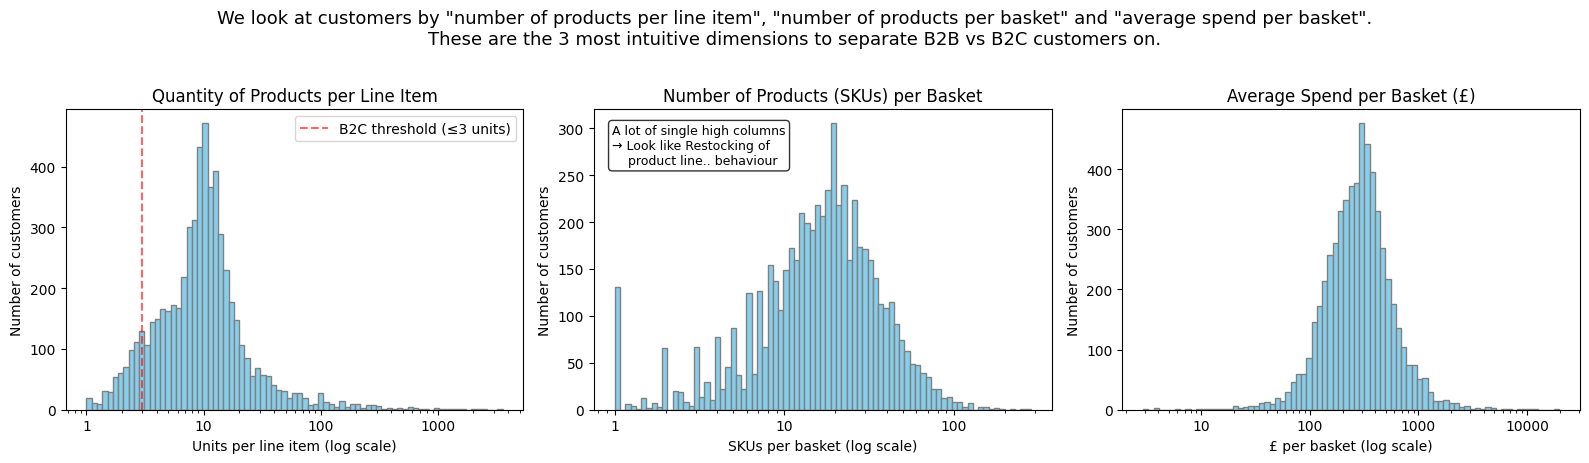

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

bins      = 80          # fewer bins on a log scale reads cleaner
color     = 'skyblue'
edgecolor = 'grey'

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('We look at customers by "number of products per line item", "number of products per basket" and "average spend per basket".\nThese are the 3 most intuitive dimensions to separate B2B vs B2C customers on.',
             fontsize=13, y=1.02)

# ── Plot 1: Avg quantity per line ─────────────────────────────────────────
# Use log-spaced bins so the histogram is evenly distributed on a log axis
qty   = customer['avg_qty_per_line'].clip(lower=0.5)
edges = np.logspace(np.log10(qty.min()), np.log10(qty.max()), bins)

ax[0].hist(qty, bins=edges, color=color, edgecolor=edgecolor)
ax[0].set_xscale('log')
ax[0].set_title('Quantity of Products per Line Item')
ax[0].set_xlabel('Units per line item (log scale)')
ax[0].set_ylabel('Number of customers')
ax[0].xaxis.set_major_formatter(mticker.ScalarFormatter())  # show 1, 10, 100 not 10^0

ax[0].axvline(3, color='red', ls='--', alpha=0.6,
              label='B2C threshold (≤3 units)')
ax[0].legend()


# ── Plot 2: Avg basket breadth ────────────────────────────────────────────
brd   = customer['avg_basket_breadth'].clip(lower=0.5)
edges = np.logspace(np.log10(brd.min()), np.log10(brd.max()), bins)

ax[1].hist(brd, bins=edges, color=color, edgecolor=edgecolor)
ax[1].set_xscale('log')
ax[1].set_title('Number of Products (SKUs) per Basket')
ax[1].set_xlabel('SKUs per basket (log scale)')
ax[1].set_ylabel('Number of customers')
ax[1].xaxis.set_major_formatter(mticker.ScalarFormatter())

ax[1].text(0.04, 0.95, 'A lot of single high columns\n→ Look like Restocking of\n    product line.. behaviour',
           transform=ax[1].transAxes, va='top', fontsize=9,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# ── Plot 3: Avg basket value ──────────────────────────────────────────────
val   = customer['avg_basket_value'].clip(lower=1)
edges = np.logspace(np.log10(val.min()), np.log10(val.max()), bins)

ax[2].hist(val, bins=edges, color=color, edgecolor=edgecolor)
ax[2].set_xscale('log')
ax[2].set_title('Average Spend per Basket (£)')
ax[2].set_xlabel('£ per basket (log scale)')
ax[2].set_ylabel('Number of customers')
ax[2].xaxis.set_major_formatter(mticker.ScalarFormatter())


plt.tight_layout()
plt.show()

---
There is nothing obvious in the above to suggest B2C customers ..
- Let's plot item quantity versus basket breadth to see if there is any significant B2C concentration in the bottom left corner

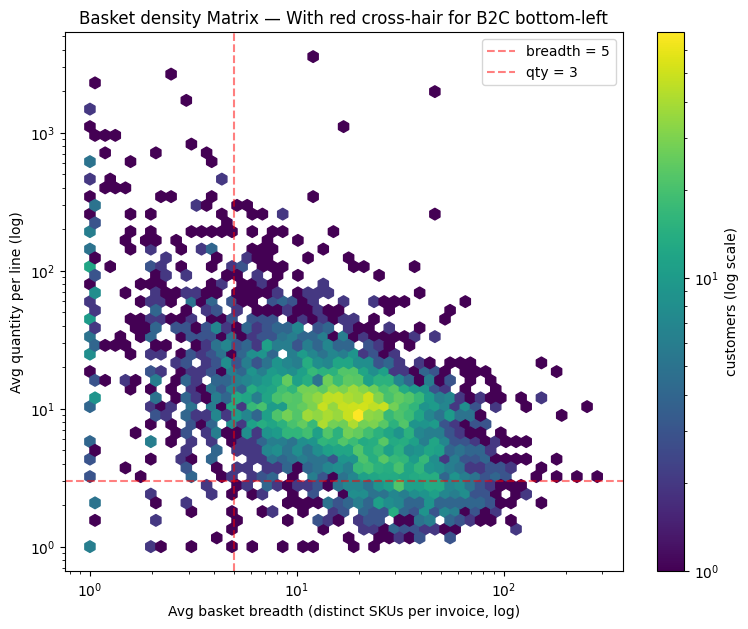

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

x = customer['avg_basket_breadth'].clip(lower=0.5)
y = customer['avg_qty_per_line'].clip(lower=0.5)

fig, ax = plt.subplots(figsize=(9,7))
hb = ax.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
               norm=LogNorm(), cmap='viridis', mincnt=1)
ax.set_xlabel('Avg basket breadth (distinct SKUs per invoice, log)')
ax.set_ylabel('Avg quantity per line (log)')
ax.set_title('Basket density Matrix — With red cross-hair for B2C bottom-left')
plt.colorbar(hb, ax=ax, label='customers (log scale)')

# Reference lines for a "B2C-like" zone
ax.axvline(5, color='red', ls='--', alpha=0.5, label='breadth = 5')
ax.axhline(3, color='red', ls='--', alpha=0.5, label='qty = 3')
ax.legend()
plt.show()

Those 4 graphs suggest this company is B2B only. 
- Even the 10^0 cluster far left is a vertical line going high on quantity suggesting stock replenishment for one or several products.

---
# Check for B2C specifically

In [16]:
b2c_candidates = customer[
    (customer['avg_qty_per_line']   <= 2)   &
    (customer['avg_basket_breadth'] >= 3)   &
    (customer['avg_basket_breadth'] <= 25)  &
    (customer['avg_basket_value']   <= 50)  &
    (customer['total_n_invoices']         <= 2)
].copy()

print(f"B2C-likeliest candidates: {len(b2c_candidates)} of {len(customer)} "
      f"({len(b2c_candidates)/len(customer):.1%})")

if len(b2c_candidates):
    cand_tx = df[df['CustomerHashID'].isin(b2c_candidates['CustomerHashID'])]
    print("\nTop products they buy:")
    print(cand_tx.groupby('Description').size()
                  .sort_values(ascending=False).head(20))
    print("\nCountry mix (by customer):")
    print("\nMedian profile:")
    print(b2c_candidates[['avg_basket_breadth','avg_qty_per_line',
                          'avg_basket_value','total_revenue']].median().round(2))

B2C-likeliest candidates: 6 of 5821 (0.1%)

Top products they buy:
Description
CHILLI LIGHTS                         2
AIRLINE BAG VINTAGE WORLD CHAMPION    1
RAIN PONCHO                           1
TEA TIME PARTY BUNTING                1
TABLECLOTH RED APPLES DESIGN          1
SWEETHEART 3 TIER CAKE STAND          1
SET OF 3 BLACK FLYING DUCKS           1
SEASIDE FLYING DISC                   1
SAVOY ART DECO CLOCK                  1
S 4 GROOVY CAT MAGNETS                1
ROSE DU SUD WASHBAG                   1
REX CASH CARRY JUMBO SHOPPER          1
RED WHITE DOTS RUFFLED UMBRELLA       1
RED SPOTTY WASHBAG                    1
RED HEARTS LIGHT CHAIN                1
RAIN PONCHO RETROSPOT                 1
PINK KNITTED COW STUFFED TOY          1
ALARM CLOCK BAKELIKE GREEN            1
PINK JUMPER LARRY THE LAMB            1
PARTY BUNTING                         1
dtype: int64

Country mix (by customer):

Median profile:
avg_basket_breadth     5.00
avg_qty_per_line       1.20
avg_bas

---
---
# We add more useful fields for analysis downstream

## We add percentage orders during business hours (UK) or evening weekend
- `pct_business_hours` and `pct_weekend` from `InvoiceDateMin`

In [15]:
# Business hours = Mon-Fri (weekday 0-4), 08:00 to 17:59 inclusive
# Evening hours = Mon-Fri 18:00-07:59 
# Weekends = Sat-Sun any time
# Treating all timestamps as UK time. No time saving hour change observed.

df['order_hour']    = df['InvoiceDateMin'].dt.hour
df['order_weekday'] = df['InvoiceDateMin'].dt.weekday   # 0=Mon, 6=Sun


is_weekday = df['order_weekday'].between(0, 4)

df['is_business_hours']    = is_weekday & df['order_hour'].between(8, 17)   # Mon-Fri 08:00-17:59
df['is_after_hours_wkday'] = is_weekday & ~df['order_hour'].between(8, 17)  # Mon-Fri 18:00-07:59
df['is_weekend']           = df['order_weekday'] >= 5                       # Sat-Sun any time


pct_hours = df.groupby('CustomerHashID').agg(
    pct_business_hours    = ('is_business_hours',    'mean'),
    pct_after_hours_wkday = ('is_after_hours_wkday', 'mean'),
    pct_weekend           = ('is_weekend',           'mean'),
)

customer = customer.drop(columns=['pct_business_hours','pct_after_hours_wkday','pct_weekend'], errors='ignore')
customer = customer.merge(pct_hours, on='CustomerHashID', how='left')

I should include the below but put it in a feature data validation section at the bottom

<Axes: title={'center': 'Order hour by BST vs GMT period'}, xlabel='order_hour'>

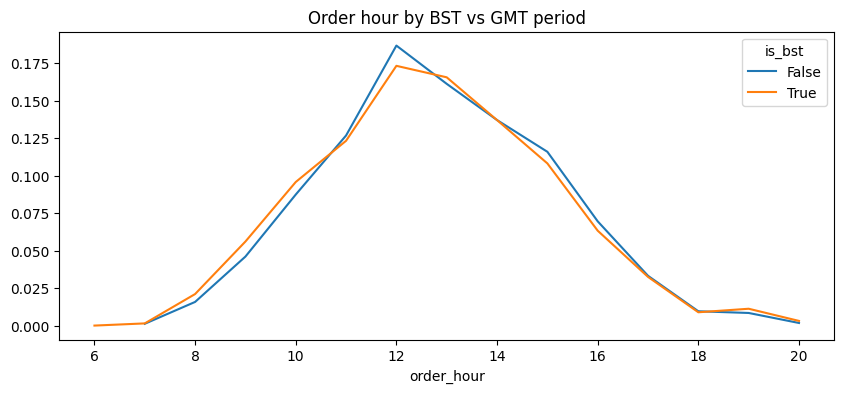

In [18]:
df['month']      = df['InvoiceDateMin'].dt.month
df['is_bst']     = df['month'].between(4, 10)   # rough BST window (Apr-Oct)

# Compare hour distributions for BST vs GMT periods
hour_dist = (df.groupby(['is_bst','order_hour']).size()
               .unstack(level=0)
               .div(df.groupby('is_bst').size()))    # normalise to proportion within each period
hour_dist.plot(kind='line', figsize=(10,4), title='Order hour by BST vs GMT period')

---
We update most common customer country as country_mode

In [16]:
# Most common country per customer (handles ties by taking the first alphabetically)
country_mode = (df.groupby('CustomerHashID')['Country']
                  .agg(lambda x: x.mode().iloc[0])
                  .rename('country_mode'))

customer = customer.drop(columns=['country_mode'], errors='ignore')
customer = customer.merge(country_mode, on='CustomerHashID', how='left')

we check how many customers order from multiple countries. 12

In [20]:
# How many customers ordered from more than one country?
multi_country = df.groupby('CustomerHashID')['Country'].nunique()
print('Customers with >1 country:', (multi_country > 1).sum())
print('Distribution:')
print(multi_country.value_counts().sort_index())

Customers with >1 country: 12
Distribution:
Country
1    5809
2      12
Name: count, dtype: int64


---
---
# We Look at Firmographic

In [21]:
# Check the country list and count
uniq_country = customer.groupby('country_mode')['country_mode'].value_counts().sort_index()
print(uniq_country)

country_mode
AUSTRALIA                 14
AUSTRIA                   11
BAHRAIN                    2
BELGIUM                   28
BRAZIL                     2
CANADA                     5
CHANNEL ISLANDS           13
CYPRUS                    10
CZECH REPUBLIC             1
DENMARK                    8
EUROPEAN COMMUNITY         1
FINLAND                   12
FRANCE                    92
GERMANY                  105
GREECE                     4
ICELAND                    1
IRELAND                    3
ISRAEL                     4
ITALY                     17
JAPAN                     10
KOREA                      2
LEBANON                    1
LITHUANIA                  1
MALTA                      2
NETHERLANDS               22
NIGERIA                    1
NORWAY                    12
POLAND                     6
PORTUGAL                  22
SAUDI ARABIA               1
SINGAPORE                  1
SOUTH AFRICA               2
SPAIN                     34
SWEDEN                    19
S

---
## We apply the following groupings:
| **country_mode**     | **region**      | **sub_region**            | **count** |
| :------------------- | :-------------- | :------------------------ | :-------- |
| AUSTRALIA            | APAC            | OCEANIA                   | 14        |
| AUSTRIA              | EMEA            | EUROPE / DACH             | 11        |
| BAHRAIN              | EMEA            | MIDDLE EAST               | 2         |
| BELGIUM              | EMEA            | EUROPE / BENELUX          | 28        |
| BRAZIL               | AMER            | AMER / LATAM              | 2         |
| CANADA               | AMER            | AMER / NORAM              | 5         |
| CHANNEL ISLANDS      | CHANNEL ISLANDS | CHANNEL ISLANDS           | 13        |
| CYPRUS               | EMEA            | EUROPE / MEDITERRANEAN    | 10        |
| CZECH REPUBLIC       | EMEA            | EUROPE / CEE              | 1         |
| DENMARK              | EMEA            | EUROPE / NORDICS          | 9         |
| EUROPEAN COMMUNITY   | EMEA            | POLITICAL/REGIONAL ENTITY | 1         |
| FINLAND              | EMEA            | EUROPE / NORDICS          | 13        |
| FRANCE               | EMEA            | EUROPE / CENTRAL          | 93        |
| GERMANY              | EMEA            | EUROPE / DACH             | 106       |
| GREECE               | EMEA            | EUROPE / MEDITERRANEAN    | 5         |
| ICELAND              | EMEA            | EUROPE / NORDICS          | 1         |
| IRELAND              | EMEA            | EUROPE / NORTHERN         | 3         |
| ISRAEL               | EMEA            | MIDDLE EAST               | 4         |
| ITALY                | EMEA            | EUROPE / MEDITERRANEAN    | 17        |
| JAPAN                | APAC            | EAST ASIA                 | 10        |
| KOREA                | APAC            | EAST ASIA                 | 2         |
| LEBANON              | EMEA            | MIDDLE EAST               | 1         |
| LITHUANIA            | EMEA            | EUROPE / BALTICS          | 1         |
| MALTA                | EMEA            | EUROPE / MEDITERRANEAN    | 2         |
| NETHERLANDS          | EMEA            | EUROPE / BENELUX          | 22        |
| NIGERIA              | EMEA            | AFRICA                    | 1         |
| NORWAY               | EMEA            | EUROPE / NORDICS          | 12        |
| POLAND               | EMEA            | EUROPE / CEE              | 6         |
| PORTUGAL             | EMEA            | EUROPE / IBERIA           | 22        |
| SAUDI ARABIA         | EMEA            | MIDDLE EAST               | 1         |
| SINGAPORE            | APAC            | SOUTHEAST ASIA            | 1         |
| SOUTH AFRICA         | EMEA            | AFRICA                    | 2         |
| SPAIN                | EMEA            | EUROPE / IBERIA           | 35        |
| SWEDEN               | EMEA            | EUROPE / NORDICS          | 19        |
| SWITZERLAND          | EMEA            | EUROPE / DACH             | 22        |
| THAILAND             | APAC            | SOUTHEAST ASIA            | 1         |
| UNITED ARAB EMIRATES | EMEA            | MIDDLE EAST               | 4         |
| UNITED KINGDOM       | UK DOMESTIC     | UK DOMESTIC               | 5332      |
| UNITED STATES        | AMER            | AMER / NORAM              | 8         |
| UNSPECIFIED          | UNSPECIFIED     | UNSPECIFIED               | 6         |
| WEST INDIES          | AMER            | AMER / LATAM              | 1         |
| **TOTAL**            | **TOTAL**       | **TOTAL**                 | **5,849** |

In [17]:
# Country — actually present
customer['country_mode']

# Region — derived from country
def country_to_region(c):
    if c == 'UNITED KINGDOM':
        return 'UK DOMESTIC'
    elif c == 'CHANNEL ISLANDS':
        return 'CHANNEL ISLANDS'
    elif c == 'UNSPECIFIED':
        return 'UNSPECIFIED'
    elif c in ['BRAZIL', 'CANADA', 'UNITED STATES', 'WEST INDIES']:
        return 'AMER'
    elif c in ['AUSTRALIA', 'JAPAN', 'KOREA' ,'SINGAPORE' ,'THAILAND']:
        return 'APAC'
    else:
        return 'EMEA'
    
# Sub-Region — derived from country
def country_to_subregion(cs):
    if cs == 'UNITED KINGDOM':
        return 'UK DOMESTIC'
    elif cs == 'CHANNEL ISLANDS':
        return 'CHANNEL ISLANDS'
    elif cs == 'IRELAND':
        return 'EUROPE / NORTHERN'
    elif cs in ['BRAZIL', 'WEST INDIES']:
        return 'AMER / LATAM'
    elif cs in ['CANADA', 'UNITED STATES']:
        return 'AMER / NORAM'
    elif cs in ['AUSTRALIA']:
        return 'OCEANIA'
    elif cs == 'EUROPEAN COMMUNITY':
        return 'POLITICAL / REGIONAL ENTITY'
    elif cs in ['AUSTRIA', 'GERMANY', 'SWITZERLAND']:
        return 'EUROPE / DACH'
    elif cs in ['BELGIUM', 'NETHERLANDS']:
        return 'EUROPE / BENELUX'
    elif cs in ['CYPRUS', 'GREECE', 'ITALY', 'MALTA']:
        return 'EUROPE / MEDITERRANEAN'
    elif cs in ['CZECH REPUBLIC', 'POLAND']:
        return 'EUROPE / CEE'
    elif cs in ['DENMARK', 'FINLAND', 'ICELAND', 'NORWAY', 'SWEDEN']:
        return 'EUROPE / NORDICS'
    elif cs in ['FRANCE']:
        return 'EUROPE / CENTRAL'
    elif cs in ['LITHUANIA']:
        return 'EUROPE / BALTICS'
    elif cs in ['PORTUGAL', 'SPAIN']:
        return 'EUROPE / IBERIA'
    elif cs in ['BAHRAIN', 'ISRAEL', 'LEBANON', 'SAUDI ARABIA', 'UNITED ARAB EMIRATES']:
        return 'MIDDLE EAST'
    elif cs in ['JAPAN', 'KOREA']:
        return 'EAST ASIA'
    elif cs in ['SINGAPORE' ,'THAILAND']:
        return 'SOUTHEAST ASIA'
    elif cs in ['NIGERIA', 'SOUTH AFRICA']:
        return 'AFRICA'
    else:
        return 'UNSPECIFIED'

customer['region'] = customer['country_mode'].apply(country_to_region)
customer['sub_region'] = customer['country_mode'].apply(country_to_subregion)

# naming convention change KOREA to SOUTH KOREA
customer['country_mode'] = customer['country_mode'].replace('KOREA', 'SOUTH KOREA')

In [23]:
# Check the region list and count
# Option 3 — as a tidy DataFrame with a named count column (nicest for further use)
uniq_region = (customer.groupby(['region','sub_region'])
                       .size()
                       .reset_index(name='n_customers')
                       .sort_values(['region','sub_region']))
print(uniq_region)

             region                   sub_region  n_customers
0              AMER                 AMER / LATAM            3
1              AMER                 AMER / NORAM           12
2              APAC                    EAST ASIA           12
3              APAC                      OCEANIA           14
4              APAC               SOUTHEAST ASIA            2
5   CHANNEL ISLANDS              CHANNEL ISLANDS           13
6              EMEA                       AFRICA            3
7              EMEA             EUROPE / BALTICS            1
8              EMEA             EUROPE / BENELUX           50
9              EMEA                 EUROPE / CEE            7
10             EMEA             EUROPE / CENTRAL           92
11             EMEA                EUROPE / DACH          138
12             EMEA              EUROPE / IBERIA           56
13             EMEA       EUROPE / MEDITERRANEAN           33
14             EMEA             EUROPE / NORDICS           52
15      

---
### RFM checks

In [24]:
# Each bucket should contain ~20% of customers
customer_ltm[['R','F','M']].apply(lambda c: c.value_counts(normalize=True).sort_index())

,R,F,M
1,0.199953,0.200187,0.200187
2,0.196454,0.199953,0.199953
3,0.199487,0.199953,0.199953
4,0.195987,0.199953,0.199953
5,0.208119,0.199953,0.199953


count    4286.000000
mean        9.014932
std         3.550635
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_score, dtype: float64


<Axes: >

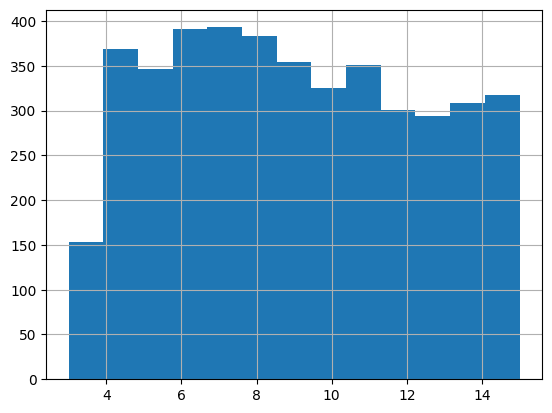

In [25]:
# Top 10 most populated RFM cells — shows where your customer base concentrates
# print(customer_ltm['RFM_cell'].value_counts().head(10))

# RFM_score distribution — should look roughly normal-ish, peaked around 9
print(customer_ltm['RFM_score'].describe())
customer_ltm['RFM_score'].hist(bins=13)

In [26]:
# Quick check to confirm the corners are dense
print(customer_ltm['RFM_cell'].value_counts().head(5))
# (1,1,1) and (5,5,5) should both feature prominently

RFM_cell
555    317
455    197
121    169
111    153
112    111
Name: count, dtype: int64


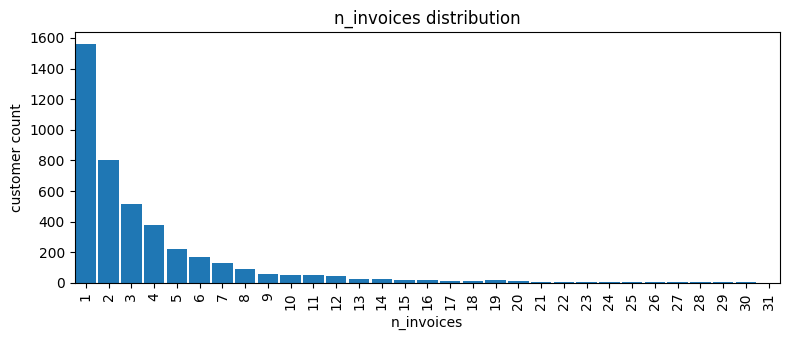

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3.5))

customer_ltm['ltm_n_invoices'].value_counts().sort_index().plot.bar(width=0.9)
plt.title('n_invoices distribution')
plt.xlabel('n_invoices')
plt.ylabel('customer count')
plt.xlim(-0.5, 30.5)   # zoom to the dense part

plt.tight_layout(); plt.show()

In [28]:
for col in ['R','F','M']:
    print(f'{col} bucket sizes:')
    print(customer_ltm[col].value_counts().sort_index())
    print()

R bucket sizes:
R
1    857
2    842
3    855
4    840
5    892
Name: count, dtype: int64

F bucket sizes:
F
1    858
2    857
3    857
4    857
5    857
Name: count, dtype: int64

M bucket sizes:
M
1    858
2    857
3    857
4    857
5    857
Name: count, dtype: int64



In [29]:
print('Recency (days since last purchase) by R bucket:')
print(customer_ltm.groupby('R')['ltm_recency_days'].agg(['min','max','count']))

print('\nFrequency (n_invoices) by F bucket:')
print(customer_ltm.groupby('F')['ltm_n_invoices'].agg(['min','max','count']))

print('\nMonetary (total_revenue) by M bucket:')
print(customer_ltm.groupby('M')['ltm_revenue'].agg(['min','max','count']))

Recency (days since last purchase) by R bucket:
   min  max  count
R                 
1  177  363    857
2   69  176    842
3   33   68    855
4   13   32    840
5    0   12    892

Frequency (n_invoices) by F bucket:
   min  max  count
F                 
1    1    1    858
2    1    2    857
3    2    3    857
4    3    5    857
5    5  194    857

Monetary (total_revenue) by M bucket:
       min        max  count
M                           
1     2.90     252.10    858
2   252.42     490.65    857
3   491.86     922.10    857
4   922.12    2007.40    857
5  2008.99  276006.37    857


In [30]:
customer.loc[customer['F']==5, 'total_n_invoices'].describe()
customer.loc[customer['F']==5, 'total_n_invoices'].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

0.50     15.0
0.75     23.0
0.90     36.4
0.95     53.2
0.99    142.0
Name: total_n_invoices, dtype: float64

In [31]:
# 1. Filter the dataframe to ONLY the unclassified customers
unclassified = customer[customer['lifecycle_segment'] == 'UNCLASSIFIED'].copy()

# 2. Combine the R, F, and M columns into a single string (e.g., R=2, F=2, M=3 becomes '223')
unclassified['RFM_pattern'] = (
    unclassified['R'].astype(str) + 
    unclassified['F'].astype(str) + 
    unclassified['M'].astype(str)
)

# 3. Print the counts of these missing patterns
print("Missing RFM Combinations (R-F-M):")
print(unclassified['RFM_pattern'].value_counts())

Missing RFM Combinations (R-F-M):
Series([], Name: count, dtype: int64)


Champions and Hibernating are about 22% each. We can check hibernating versus seaonaility later, lets look at grapphs

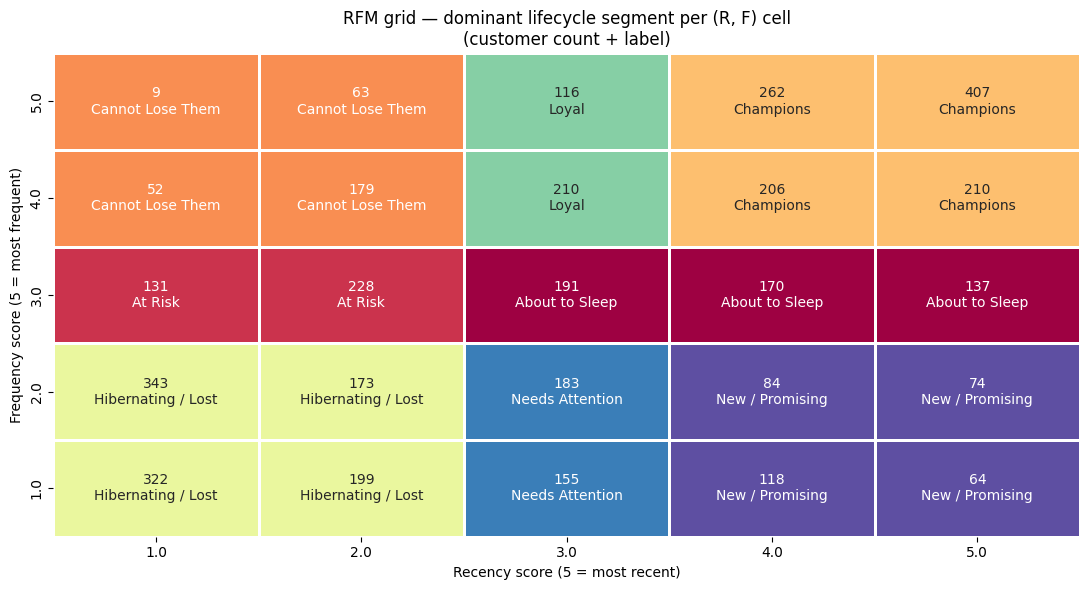

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build the label→int map
labels_unique = sorted(customer['lifecycle_segment'].dropna().unique())
label_to_int  = {lbl: i for i, lbl in enumerate(labels_unique)}
int_to_label  = {i: lbl for lbl, i in label_to_int.items()}

# Add an integer code column on customer, then groupby it directly — avoids dtype issues
customer['_lifecycle_code'] = customer['lifecycle_segment'].map(label_to_int)

# For each (R, F) cell, take the modal code
grid_numeric = (customer.groupby(['F','R'])['_lifecycle_code']
                        .agg(lambda x: x.mode().iloc[0])
                        .unstack('R')
                        .astype(float))

# Customer counts per cell
counts = (customer.groupby(['F','R']).size()
                  .unstack('R').fillna(0).astype(int))

# Build annotation: "count\nlabel" for populated cells, '' for empty
annot = pd.DataFrame('', index=grid_numeric.index, columns=grid_numeric.columns)
for r in grid_numeric.index:
    for c in grid_numeric.columns:
        v = grid_numeric.loc[r, c]
        if pd.notna(v):
            annot.loc[r, c] = f"{counts.loc[r, c]:,}\n{int_to_label[int(v)]}"

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(grid_numeric.iloc[::-1],         # flip so F=5 sits at the top
            annot=annot.iloc[::-1],
            fmt='',
            cmap='Spectral',
            cbar=False,
            linewidths=1,
            linecolor='white',
            ax=ax)
ax.set_title('RFM grid — dominant lifecycle segment per (R, F) cell\n(customer count + label)')
ax.set_xlabel('Recency score (5 = most recent)')
ax.set_ylabel('Frequency score (5 = most frequent)')
plt.tight_layout()
plt.show()

# Tidy up
customer = customer.drop(columns='_lifecycle_code')

In [30]:
print(grid_numeric.dtypes)
print(grid_numeric)

R
1.0    float64
2.0    float64
3.0    float64
4.0    float64
5.0    float64
dtype: object
R    1.0  2.0   3.0   4.0   5.0
F                              
1.0  7.0  7.0  11.0  12.0  12.0
2.0  7.0  7.0  11.0  12.0  12.0
3.0  1.0  1.0   0.0   0.0   0.0
4.0  3.0  3.0   9.0   4.0   4.0
5.0  3.0  3.0   9.0   4.0   4.0


In [31]:
# !pip install squarify

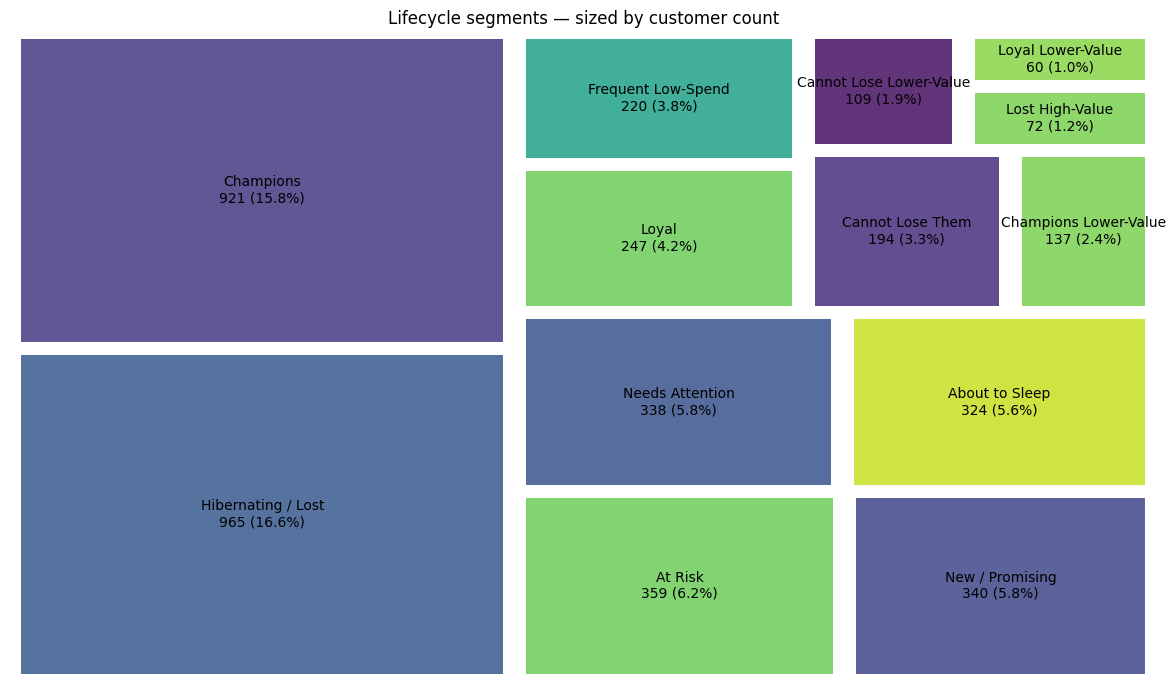

In [32]:
import squarify
import matplotlib.pyplot as plt

seg_counts = customer['lifecycle_segment'].value_counts()
labels = [f'{name}\n{count:,} ({count/len(customer)*100:.1f}%)'
          for name, count in seg_counts.items()]

plt.figure(figsize=(12, 7))
squarify.plot(sizes=seg_counts.values,
              label=labels,
              alpha=0.85,
              pad=True,
              text_kwargs={'fontsize': 10, 'wrap': True})
plt.title('Lifecycle segments — sized by customer count')
plt.axis('off')
plt.tight_layout()
plt.show()

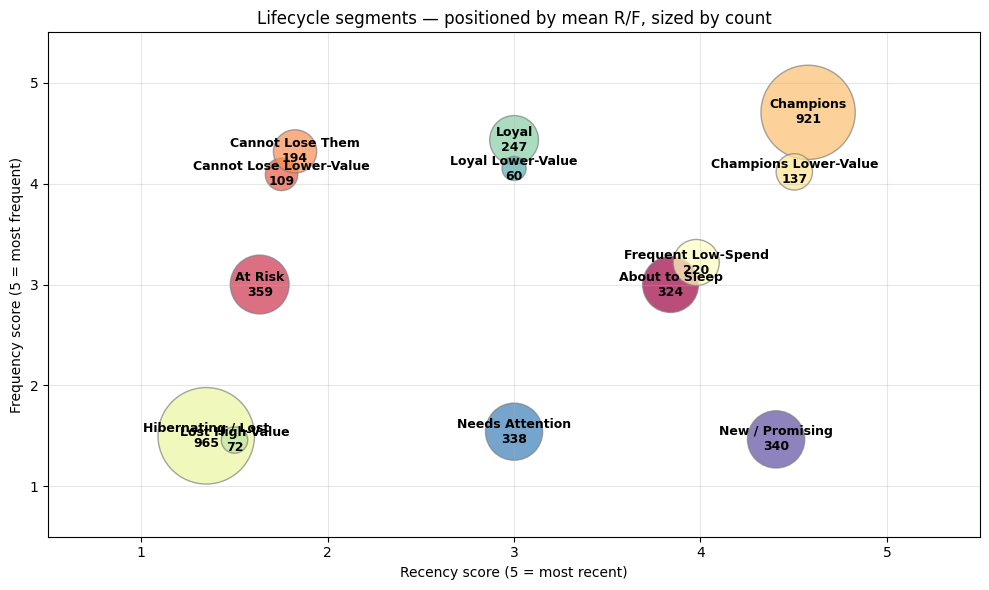

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Compute centroid (R,F) for each segment, weighted by count, plus segment size
seg_summary = (customer.groupby('lifecycle_segment')
                       .agg(R_mean=('R','mean'),
                            F_mean=('F','mean'),
                            count=('CustomerHashID','count'))
                       .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(seg_summary['R_mean'],
                     seg_summary['F_mean'],
                     s=seg_summary['count'] * 5,    # bubble size
                     c=range(len(seg_summary)),
                     cmap='Spectral',
                     alpha=0.7,
                     edgecolors='grey',
                     linewidth=1)

# Label each bubble with segment name and count
for _, row in seg_summary.iterrows():
    ax.annotate(f"{row['lifecycle_segment']}\n{row['count']:,}",
                (row['R_mean'], row['F_mean']),
                ha='center', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Recency score (5 = most recent)')
ax.set_ylabel('Frequency score (5 = most frequent)')
ax.set_title('Lifecycle segments — positioned by mean R/F, sized by count')
ax.set_xlim(0.5, 5.5); ax.set_ylim(0.5, 5.5)
ax.set_xticks(range(1, 6)); ax.set_yticks(range(1, 6))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

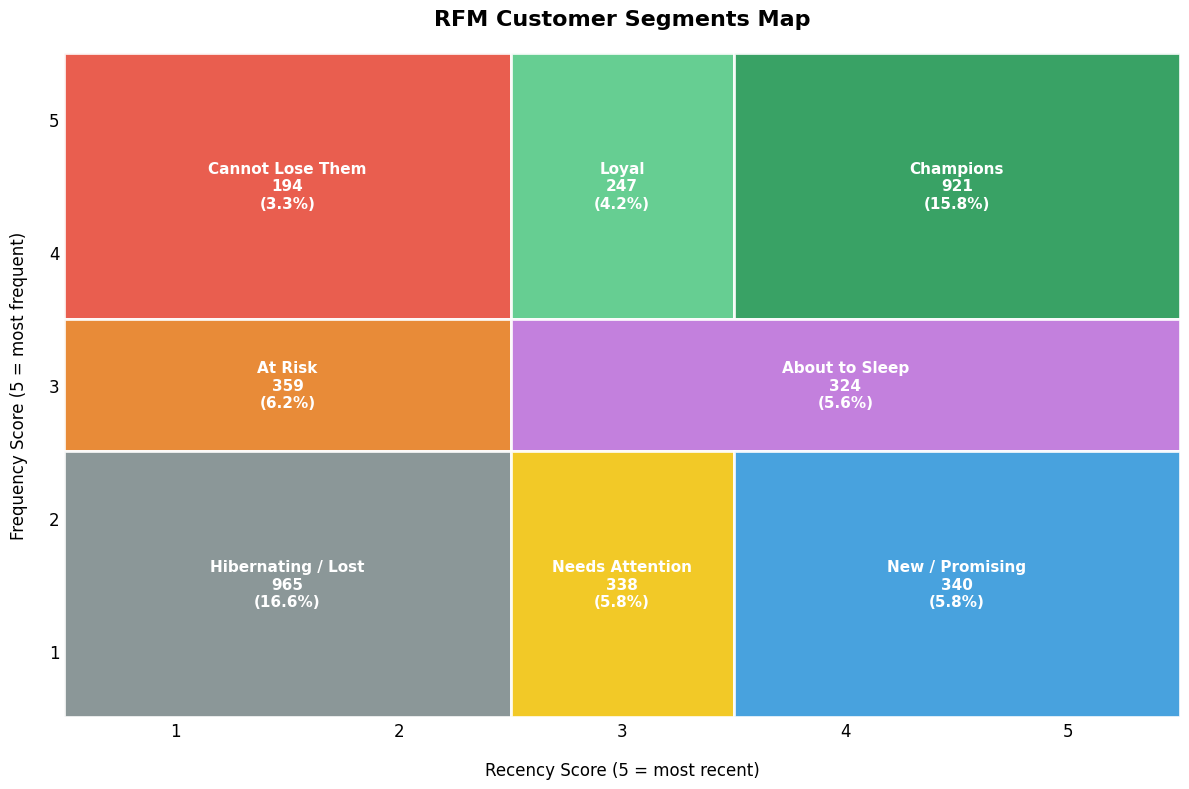

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Get customer counts and percentages (same as your previous code)
seg_counts = customer['lifecycle_segment'].value_counts()
total_customers = len(customer)

# 2. Use your exact custom color map
colour_map = {
    'Champions':           "#239854",
    'Loyal':               "#55c986",
    'Cannot Lose Them':         '#e74c3c',
    'At Risk':                        '#e67e22',
    'Needs Attention':                '#f1c40f',
    'About to Sleep':                 '#bd72da',
    'Hibernating / Lost':             '#7f8c8d',
    'New / Promising':                '#3498db',
    'Frequent Low-Spend':             "#9b59b6", 
}

# 3. Define the fixed coordinates for each segment on a 5x5 grid.
# Format: 'Segment Name': (x_start, y_start, width, height)
# x = Recency (0 to 5), y = Frequency (0 to 5)
segment_boxes = {
    'Cannot Lose Them':   (0, 3, 2, 2),  # R:1-2, F:4-5
    'Loyal':         (2, 3, 1, 2),  # R:3,   F:4-5
    'Champions':     (3, 3, 2, 2),  # R:4-5, F:4-5
    
    'At Risk':                  (0, 2, 2, 1),  # R:1-2, F:3
    'About to Sleep':           (2, 2, 3, 1),  # R:3-5, F:3
    
    'Hibernating / Lost':       (0, 0, 2, 2),  # R:1-2, F:1-2
    'Needs Attention':          (2, 0, 1, 2),  # R:3,   F:1-2
    'New / Promising':          (3, 0, 2, 2),  # R:4-5, F:1-2
}

# Create the figure
fig, ax = plt.subplots(figsize=(12, 8))

# 4. Loop through the boxes, draw them, and add the text
for seg, (x, y, w, h) in segment_boxes.items():
    
    # Get the count and calc percentage (handle missing segments gracefully)
    count = seg_counts.get(seg, 0)
    pct = (count / total_customers) * 100
    label_text = f"{seg}\n{count:,}\n({pct:.1f}%)"
    
    # Draw the rectangle
    rect = patches.Rectangle(
        (x, y), w, h, 
        linewidth=2, 
        edgecolor='white', # Creates the gap/border between boxes
        facecolor=colour_map.get(seg, '#333333'), 
        alpha=0.9
    )
    ax.add_patch(rect)
    
    # Add the text in the center of the rectangle
    ax.text(
        x + w/2, y + h/2, 
        label_text, 
        ha='center', va='center', 
        color='white', fontsize=11, fontweight='bold',
        wrap=True
    )

# 5. Format the axes to look like an RFM grid
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

# Set ticks to be in the middle of the blocks (0.5, 1.5, 2.5, etc.)
ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])

# Label the ticks 1 to 5
ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=12)
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=12)

ax.set_xlabel('Recency Score (5 = most recent)', fontsize=12, labelpad=15)
ax.set_ylabel('Frequency Score (5 = most frequent)', fontsize=12, labelpad=15)
ax.set_title('RFM Customer Segments Map', fontsize=16, fontweight='bold', pad=20)

# Remove the outer spines for a cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove tick marks (keep the labels)
ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

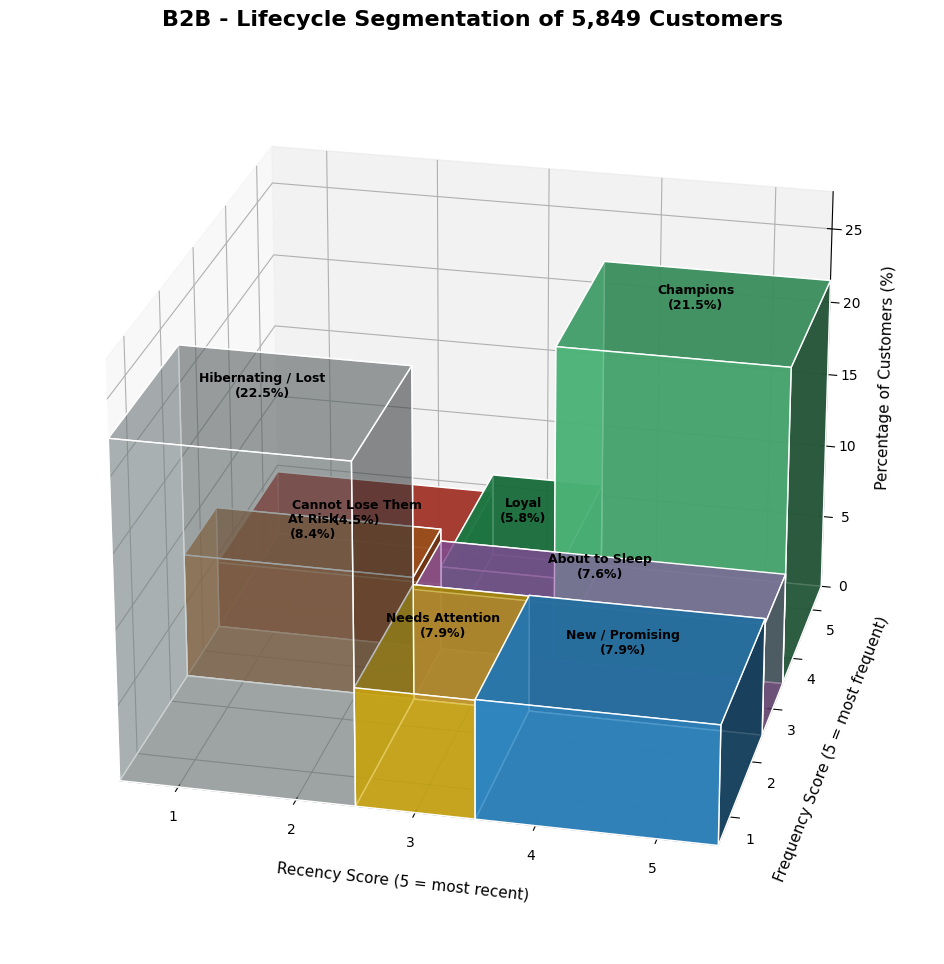

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

# 1. Setup counts and total
# seg_counts = customer_ltm['lifecycle_seg*sment'].value_counts()
seg_counts = customer_ltm['lifecycle_segment'].value_counts()
total_customers = len(customer_ltm)

# 2. Colour Map (Base Colors)
colour_map = {
    'Champions':                      '#55c986',
    'Loyal':                          '#239854',
    'Cannot Lose Them':               '#e74c3c',
    'At Risk':                        '#e67e22',
    'Needs Attention':                '#f1c40f',
    'About to Sleep':                 "#bd72da",
    'Hibernating / Lost':             '#7f8c8d',
    'New / Promising':                '#3498db',
    'Frequent Low-Spend':             "#9b59b6", 
}

# 3. NEW: Alpha (Transparency) Map
# 1.0 is completely solid, 0.0 is invisible.
# We make the tall blocks in the front transparent, and the short blocks in the back solid.
alpha_map = {
    'Hibernating / Lost':        0.35, # Very transparent
    'At Risk':                   0.50, # Semi-transparent
    'About to Sleep':            0.60, 
    'Needs Attention':           0.70, 
    'New / Promising':           0.85, # Mostly solid 
    'Loyal High-Value':          0.85, 
    'Champions High-Value':      0.95, 
    'Cannot Lose High-Value':    1.0,  # Opaque
}

# Fixed Grid Coordinates: 'Segment': (x_start, y_start, width, depth)
segment_boxes = {
    'Cannot Lose Them':          (0, 3, 2, 2),  
    'Loyal':                     (2, 3, 1, 2),  
    'Champions':                 (3, 3, 2, 2),  
    'At Risk':                   (0, 2, 2, 1),  
    'About to Sleep':            (2, 2, 3, 1),  
    'Hibernating / Lost':        (0, 0, 2, 2),  
    'Needs Attention':           (2, 0, 1, 2),  
    'New / Promising':           (3, 0, 2, 2),  
}

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos, z_pos = [], [], []
dx, dy, dz = [], [], []
colors = []
max_pct = 0

# 4. Build the 3D data arrays
for seg, (x, y, w, h) in segment_boxes.items():
    count = seg_counts.get(seg, 0)
    pct = (count / total_customers) * 100
    if pct > max_pct: max_pct = pct

    x_pos.append(x)
    y_pos.append(y)
    z_pos.append(0) 
    
    dx.append(w)
    dy.append(h)
    dz.append(pct)
    
    # --- NEW COLOR LOGIC ---
    base_color = colour_map.get(seg, '#333333')
    alpha_val = alpha_map.get(seg, 0.8) # Default to 0.8 if not in the alpha map
    
    # Convert hex to RGBA using Matplotlib's to_rgba
    rgba_color = mcolors.to_rgba(base_color, alpha_val)
    colors.append(rgba_color)
    # -----------------------

    # Add text floating slightly above the block
    label_text = f"{seg}\n({pct:.1f}%)"
    
    # make text more readable
    text_z = pct + 1.0 
    
    ax.text(
        x + (w / 2), y + (h / 2), text_z, 
        label_text, 
        ha='center', va='center', 
        fontsize=9, fontweight='bold', color='black'
    )

# 5. Draw the 3D blocks
ax.bar3d(
    x_pos, y_pos, z_pos, 
    dx, dy, dz, 
    color=colors,         # Using custom RGBA list
    edgecolor='white',  
    shade=True            
    # REMOVED alpha=0.9 from here!
)

# Formatting the Axes
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
z_limit = max(25, max_pct + 5) 
ax.set_zlim(0, z_limit)

ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_xticklabels(['1', '2', '3', '4', '5'])
ax.set_yticklabels(['1', '2', '3', '4', '5'])

ax.set_xlabel('\nRecency Score (5 = most recent)', fontsize=11, linespacing=3)
ax.set_ylabel('\nFrequency Score (5 = most frequent)', fontsize=11, linespacing=3)
ax.set_zlabel('Percentage of Customers (%)', fontsize=11, labelpad=10)

plt.title('B2B - Lifecycle Segmentation of 5,849 Customers', fontsize=16, fontweight='bold', pad=0)

ax.view_init(elev=24, azim=-77) 
plt.show()

##### Now the above is starting to look like what I want. I need to format it better (like the text) but it becomes obvious to see the groups and their size.
I need to change the colours

Okay I still need to do seasonality and the slice and dice to understand Champion persona since 22% Champion and 22% Hibernting / Lost is a different lense depending on persona.

---
### Do some tests on tier_value

In [36]:
# Ghost Whales (Used to be Key, now Standard)
ghosts = customer[(customer['historical_value_tier'] == 'Key Account') & 
                  (customer['current_value_tier'] == 'Standard Account')]

# Hidden Gems / High-Velocity Newbies (Used to be Standard, now Key)
rising_stars = customer[(customer['historical_value_tier'] == 'Standard Account') & 
                        (customer['current_value_tier'] == 'Key Account')]

display(ghosts)

,CustomerHashID,total_n_invoices,total_n_lines,total_n_skus,total_qty,total_revenue,avg_qty_per_line,median_qty_per_line,max_qty_per_line,first_purchase,...,current_value_tier,current_trajectory,current_year,customer_status_yoy,pct_business_hours,pct_after_hours_wkday,pct_weekend,country_mode,region,sub_region
111,ecdd41ff789f5ec10891a5557f01f2f5e062a1b89b85d8...,16,214,65,15873,17359.99,74.2,32.0,480,2009-12-02 15:16:00,...,Standard Account,Insufficient data,True,Existing,0.906542,0.000000,0.093458,UNITED KINGDOM,UK DOMESTIC,UK DOMESTIC
480,3e9c16ce88b8fd21a5793b670e0b4e894377d6a84d6264...,8,367,259,2910,6272.53,7.9,6.0,40,2010-01-28 15:43:00,...,Standard Account,Insufficient data,True,Existing,0.934605,0.000000,0.065395,UNITED KINGDOM,UK DOMESTIC,UK DOMESTIC
629,ca7c1720a83dc7dd4cdb21efdb2da650e6ad47e6217110...,18,136,75,2022,4994.36,14.9,12.0,96,2009-12-04 13:00:00,...,Standard Account,Insufficient data,True,Existing,0.830882,0.051471,0.117647,UNITED KINGDOM,UK DOMESTIC,UK DOMESTIC
693,881508166afb209d5206230e73cd0e057cb73168c07371...,8,231,199,2891,4579.23,12.5,12.0,64,2009-12-07 11:46:00,...,Standard Account,Insufficient data,True,Existing,1.000000,0.000000,0.000000,GREECE,EMEA,EUROPE / MEDITERRANEAN
731,c05fa6de41228e120777f976fae3c2aae2d87203c96446...,7,256,234,2024,4417.27,7.9,6.0,72,2010-02-04 14:19:00,...,Standard Account,Insufficient data,True,Existing,1.000000,0.000000,0.000000,UNITED KINGDOM,UK DOMESTIC,UK DOMESTIC
950,9936a372b1e09ad0781781c8867fd2e589361aa2937118...,14,475,223,1735,3475.44,3.7,2.0,48,2009-12-03 13:02:00,...,Standard Account,Insufficient data,True,Existing,0.686316,0.061053,0.252632,UNITED KINGDOM,UK DOMESTIC,UK DOMESTIC
967,d9507d366ce9bfc97798896c509f1ec1aca2cbf8adea39...,14,356,273,1931,3429.79,5.4,1.0,100,2010-02-16 15:47:00,...,Standard Account,Insufficient data,True,Existing,0.696629,0.044944,0.258427,UNITED KINGDOM,UK DOMESTIC,UK DOMESTIC
993,22d801e4eb2fe637f01cd97d12be34ec11a205eb79ea2c...,6,124,80,1652,3358.94,13.3,12.0,60,2009-12-03 15:32:00,...,Standard Account,Insufficient data,True,Existing,0.435484,0.000000,0.564516,UNITED KINGDOM,UK DOMESTIC,UK DOMESTIC
1005,9a94374720d78789bcf9c61dff6b8efc5f41c42a5ec063...,13,187,124,2165,3330.03,11.6,10.0,64,2009-12-04 16:12:00,...,Standard Account,Insufficient data,True,Existing,0.909091,0.048128,0.042781,UNITED KINGDOM,UK DOMESTIC,UK DOMESTIC
1011,f78613891c8973d5181b96abcbd1212afdc8b55bf916a1...,11,328,155,1619,3320.84,4.9,3.0,48,2010-02-11 18:36:00,...,Standard Account,Insufficient data,True,Existing,0.310976,0.689024,0.000000,UNITED KINGDOM,UK DOMESTIC,UK DOMESTIC


#### Let's check the distributions so I can test last 12 month revenue versus total revenue

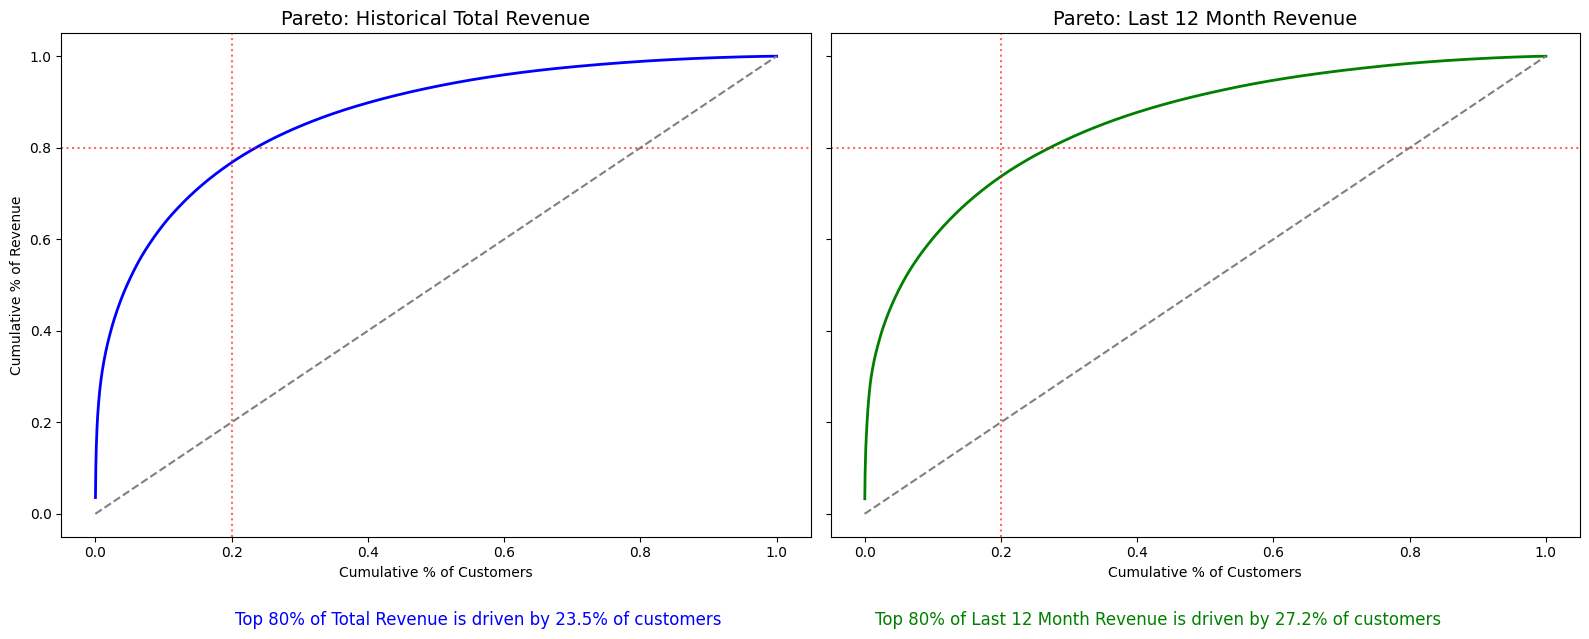

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data for Total Revenue
df_tot = customer.sort_values('total_revenue', ascending=False).reset_index(drop=True)
df_tot['cum_rev_pct'] = df_tot['total_revenue'].cumsum() / df_tot['total_revenue'].sum()
df_tot['cum_cust_pct'] = (df_tot.index + 1) / len(df_tot)

# 2. Prepare data for Last 12 month Revenue
df_ann = customer_ltm.sort_values('ltm_revenue', ascending=False).reset_index(drop=True)
df_ann['cum_rev_pct'] = df_ann['ltm_revenue'].cumsum() / df_ann['ltm_revenue'].sum()
df_ann['cum_cust_pct'] = (df_ann.index + 1) / len(df_ann)

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot A: Total Revenue
axes[0].plot(df_tot['cum_cust_pct'], df_tot['cum_rev_pct'], color='blue', lw=2)
axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--') # Line of absolute equality
axes[0].axhline(0.80, color='red', linestyle=':', alpha=0.6)
axes[0].axvline(0.20, color='red', linestyle=':', alpha=0.6)
axes[0].set_title('Pareto: Historical Total Revenue', fontsize=14)
axes[0].set_xlabel('Cumulative % of Customers')
axes[0].set_ylabel('Cumulative % of Revenue')

# Plot B: Normalised Revenue
axes[1].plot(df_ann['cum_cust_pct'], df_ann['cum_rev_pct'], color='green', lw=2)
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
axes[1].axhline(0.80, color='red', linestyle=':', alpha=0.6)
axes[1].axvline(0.20, color='red', linestyle=':', alpha=0.6)
axes[1].set_title('Pareto: Last 12 Month Revenue', fontsize=14)
axes[1].set_xlabel('Cumulative % of Customers')

# Calculate exactly how many customers make up the top 80% for both
top_80_tot = df_tot[df_tot['cum_rev_pct'] <= 0.80].shape[0] / len(df_tot)
top_80_ann = df_ann[df_ann['cum_rev_pct'] <= 0.80].shape[0] / len(df_ann)

plt.figtext(0.15, -0.05, f"Top 80% of Total Revenue is driven by {top_80_tot*100:.1f}% of customers", fontsize=12, color='blue')
plt.figtext(0.55, -0.05, f"Top 80% of Last 12 Month Revenue is driven by {top_80_ann*100:.1f}% of customers", fontsize=12, color='green')

plt.tight_layout()
plt.show()

In [34]:
# Who is in the Top 80%?
tot_key_accounts = set(df_tot[df_tot['cum_rev_pct'] <= 0.80]['CustomerHashID'])
ann_key_accounts = set(df_ann[df_ann['cum_rev_pct'] <= 0.80]['CustomerHashID'])

# Calculate the difference
dropped_out = len(tot_key_accounts - ann_key_accounts)
newly_promoted = len(ann_key_accounts - tot_key_accounts)

print(f"By addressing >1 year historical bias, {dropped_out} legacy customers are moved out of the Key Account tier.")
print(f"They were replaced by {newly_promoted} active customers who are driving current value.")

By addressing >1 year historical bias, 361 legacy customers are moved out of the Key Account tier.
They were replaced by 155 active customers who are driving current value.


---
### Let's check lifecycle_segment, value_tier and trajectory

In [39]:
# 1 Are Cannot Lose Them customers actually high-value? They should be.
# pd.crosstab(customer['lifecycle_segment'], customer['current_value_tier'])

# 2 Are Champions usually Growing or Stable? Mostly yes? — declining champions are rare.
pd.crosstab(customer['lifecycle_segment'], customer['current_trajectory'])

# 3 The three-way matrix of populated personas. Note this is the first draft
# I still need seasonality, k-means on behviour, product affinity but this is a starting point for refining
# pd.crosstab([customer['lifecycle_segment'], customer['current_value_tier']], customer['current_trajectory'])

current_trajectory,Declining,Growing,Insufficient data,Stable
lifecycle_segment,,,,
About to Sleep,22,33,245,24
At Risk,15,11,320,13
Cannot Lose Lower-Value,41,16,41,11
Cannot Lose Them,79,44,35,36
Champions,227,304,72,318
Champions Lower-Value,31,43,36,27
Frequent Low-Spend,12,18,180,10
Hibernating / Lost,0,0,965,0
Lost High-Value,0,0,72,0


#### For 2 above we see significant declining champions, I need to check:
Looking at the split below, this is fine.  73% stable or growing seems about right with 23% in decline

In [40]:
champ = customer[customer['lifecycle_segment']=='Champions']
print(champ['current_trajectory'].value_counts(normalize=True))

current_trajectory
Stable               0.345277
Growing              0.330076
Declining            0.246471
Insufficient data    0.078176
Name: proportion, dtype: float64


In [17]:
declining_champs = customer[(customer['lifecycle_segment']=='Champions') & 
                            (customer['historical_trajectory']=='Declining')]
print(declining_champs[['ltm_revenue', 'ltm_n_invoices', 'ltm_recency_days', 
                        'hist_rev_slope', 'hist_rev_slope_pct', 'ltm_n_active_months']].describe())

        ltm_revenue  ltm_n_invoices  ltm_recency_days  hist_rev_slope  \
count    147.000000      147.000000        147.000000      147.000000   
mean    3547.623333        8.972789         12.972789      -38.492142   
std     5815.251880        7.506112          8.785063       60.336995   
min      926.010000        3.000000          0.000000     -517.780778   
25%     1377.540000        4.000000          5.500000      -38.518393   
50%     2179.320000        7.000000         12.000000      -20.342000   
75%     3664.920000       10.500000         19.000000      -13.634542   
max    61825.780000       53.000000         32.000000       -3.597413   

       hist_rev_slope_pct  ltm_n_active_months  
count          147.000000           147.000000  
mean            -0.091443             5.925170  
std              0.061492             2.543023  
min             -0.404773             2.000000  
25%             -0.109587             4.000000  
50%             -0.069748             5.000000  

here we can confirm mean revenue £5,202, 12 or so invoices, mild -£50 revenue slope these are declining in the top tier but not falling out
---
Let's check a few:

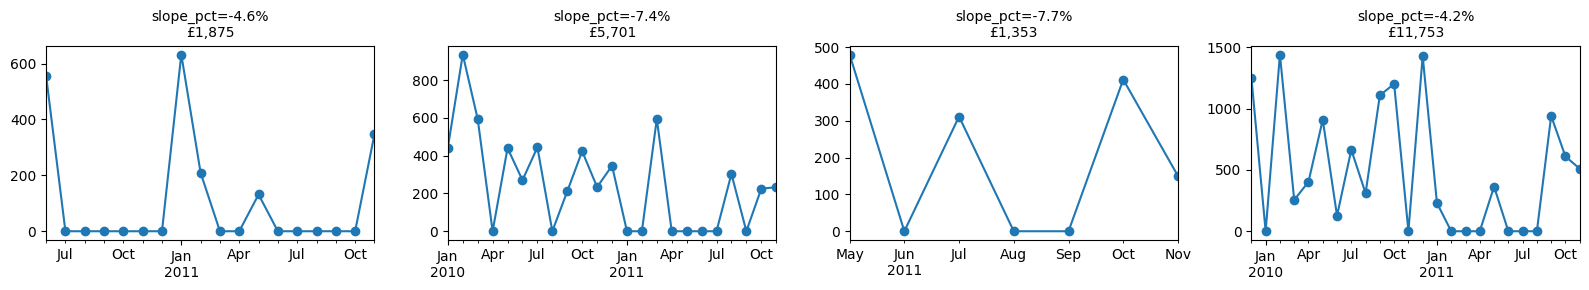

In [19]:
import matplotlib.pyplot as plt

# Pull 4 random declining Champions and plot their monthly trajectories
sample = declining_champs.sample(4, random_state=42)
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, (_, row) in zip(axes, sample.iterrows()):
    monthly = (df[df['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    monthly.plot(ax=ax, marker='o')
    ax.set_title(f"slope_pct={row['hist_rev_slope_pct']*100:.1f}%\n£{row['total_revenue']:,.0f}", 
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

**Okay there are a few things going on above from left 1 to right 4**
- 1 does look like a lower spend champion who we need to look after, outreach recommended
- 2 this looks a bit erratic, they seem to order in bursts, there might be some seasonality in here with oct - dec winter with what looks like the beginning of a repeat next oct and a mar to may spring-time, looks fine
- 3 this has an oct to oct pattern like yearly purchase, we would leave alone
- 4 one big purchase and then smaller purchases, looks like onboarding spike then stabilisation of lower purchases.

We definitely need to run the seasonality trends and then revisit this but also the above looks fine for now and we can extrapolate more from it with the K-means (behaviour based) testing and product affinities later.

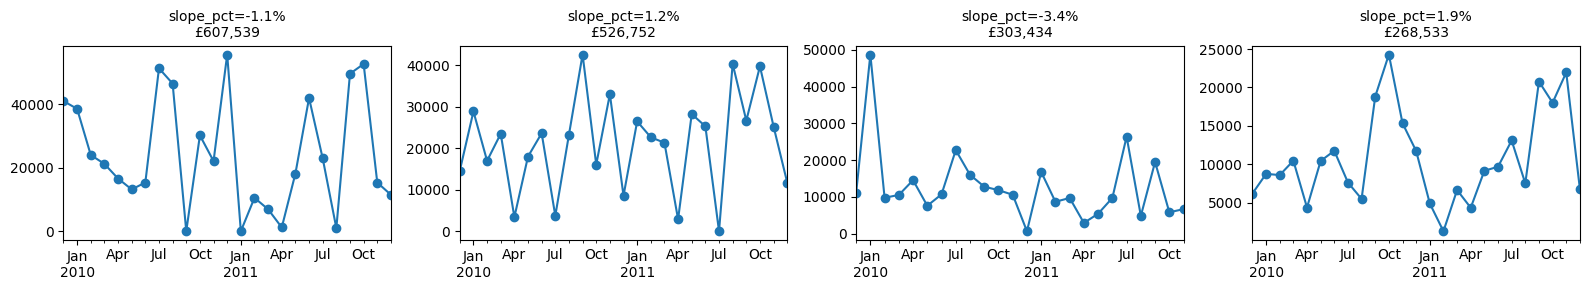

In [38]:
import matplotlib.pyplot as plt

# Pull 4 random declining Champions and plot their monthly trajectories
sample = customer
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, (_, row) in zip(axes, sample.iterrows()):
    monthly = (df[df['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    monthly.plot(ax=ax, marker='o')
    ax.set_title(f"slope_pct={row['rev_slope_pct']*100:.1f}%\n£{row['total_revenue']:,.0f}", 
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

---
---
# Seasonality

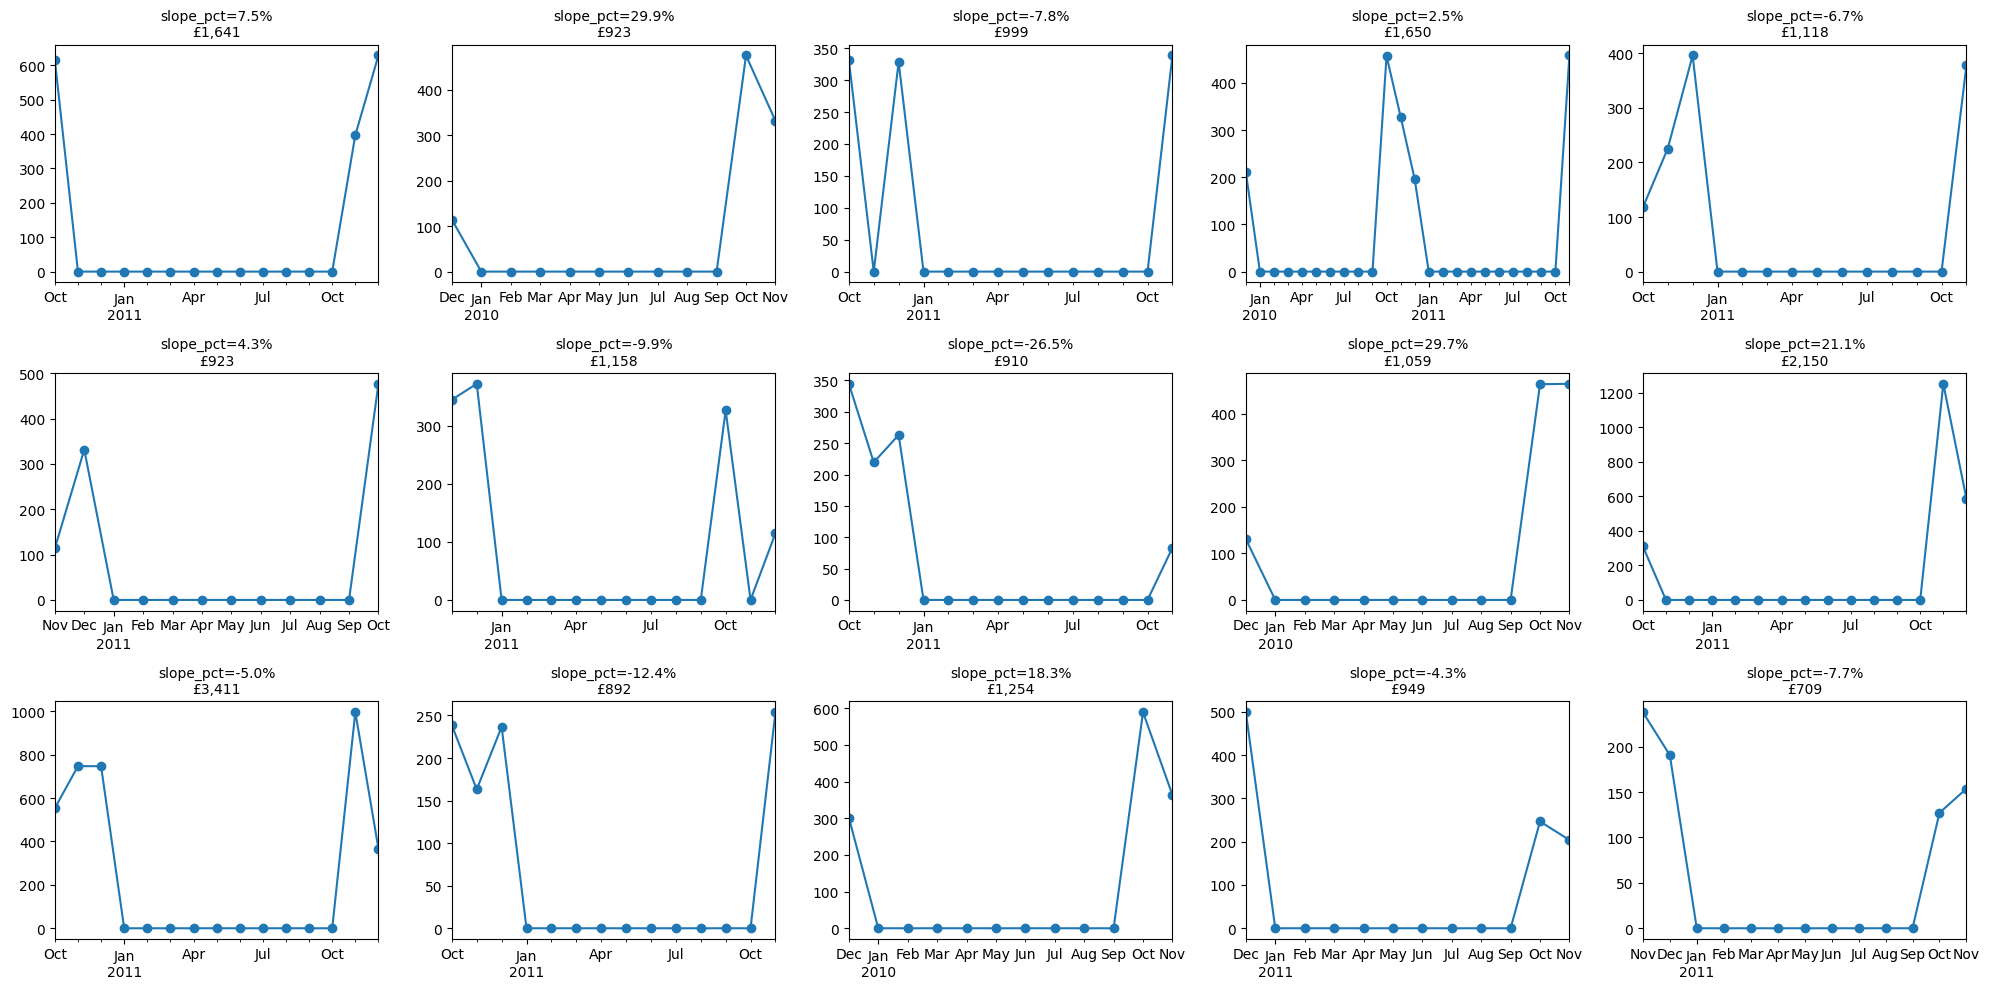

In [69]:
purchase_pattern = customer[customer['seasonality_segment'] == 'Winter Specialist']

import matplotlib.pyplot as plt

sample = purchase_pattern.sample(15, random_state=82)
fig, axes = plt.subplots(3, 5, figsize=(20, 10))

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    monthly = (df[df['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    monthly.plot(ax=ax, marker='o')
    ax.set_title(f"slope_pct={row['rev_slope_pct']*100:.1f}%\n£{row['total_revenue']:,.0f}",
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

---
---
## Manual build out of Seasonal Logic

In [18]:
invoice_count_by_month = (df.groupby([df['InvoiceDateMin'].dt.year.rename('Year'),
                                       df['InvoiceDateMin'].dt.month.rename('Month')])
                            .agg(n_invoices=('Invoice', 'nunique'),
                                 n_customers=('CustomerHashID', 'nunique'))
                            .reset_index()
                            .sort_values(['Year', 'Month']))
print(invoice_count_by_month)

    Year  Month  n_invoices  n_customers
0   2009     12        1490          949
1   2010      1         955          700
2   2010      2        1087          769
3   2010      3        1505         1050
4   2010      4        1311          939
5   2010      5        1351          961
6   2010      6        1473         1033
7   2010      7        1356          923
8   2010      8        1272          909
9   2010      9        1650         1133
10  2010     10        2101         1490
11  2010     11        2560         1603
12  2010     12        1384          883
13  2011      1         976          737
14  2011      2         988          756
15  2011      3        1307          972
16  2011      4        1128          851
17  2011      5        1538         1054
18  2011      6        1380          987
19  2011      7        1315          943
20  2011      8        1264          932
21  2011      9        1735         1257
22  2011     10        1889         1359
23  2011     11 

In [19]:
import pandas as pd

# ============================================================
# Initialise the purchase_behaviour field
# ============================================================
customer['purchase_behaviour'] = pd.NA 
customer['multiple_year_purchase'] = pd.NA 

# ============================================================
# Rule 1 — One-time purchasers
# ============================================================
mask_rule_1 = customer['total_n_invoices'] == 1
customer.loc[mask_rule_1, 'purchase_behaviour'] = 'One-Time Purchase'
customer.loc[mask_rule_1, 'multiple_year_purchase'] = False

# print(f"Rule 1 claimed: {mask.sum()} customers")
print(f"Rule 1 claimed: {mask_rule_1.sum()} customers")
# print(customer['purchase_behaviour'].value_counts(dropna=False))


# ============================================================
# Rule 2 — Yearly Repeat Purchase (2 Invoices, 11-12 month gap)
# or two year 23-24 gap
# ============================================================

# 1: Get a list of CustomerHashIDs who have exactly 2 invoices AND are unclassified
mask_2_invoices = (customer['total_n_invoices'] == 2) & (customer['purchase_behaviour'].isna())
eligible_ids = customer.loc[mask_2_invoices, 'CustomerHashID']

# 2: Filter the raw 'df' to only include line items for these specific customers
df_rule_2 = df[df['CustomerHashID'].isin(eligible_ids)]

# 3: Group by Customer to get the Date of Invoice 1 (min) and Invoice 2 (max)
df['InvoiceDateMin'] = pd.to_datetime(df['InvoiceDateMin']) 

customer_dates = df_rule_2.groupby('CustomerHashID')['InvoiceDateMin'].agg(['min', 'max'])

# 4: Calculate the gap in days
customer_dates['days_between'] = (customer_dates['max'] - customer_dates['min']).dt.days

# 5: Identify the customers where the gap is 11 to 12 months.
# 11 months is ~334 days. 12 months is ~365 days. we use 325, 375
mask_11_12_months = (customer_dates['days_between'] >= 325) & (customer_dates['days_between'] <= 375)
mask_23_24_months = (customer_dates['days_between'] >= 650) & (customer_dates['days_between'] <= 750) # add the following year

# 6: Extract just the IDs of the customers who passed this test
yearly_repeat_ids = customer_dates[mask_11_12_months].index
two_year_repeat_ids = customer_dates[mask_23_24_months].index

# 7: Update the customer table
mask_rule_2 = (customer['CustomerHashID'].isin(yearly_repeat_ids)) & (customer['purchase_behaviour'].isna())
customer.loc[mask_rule_2, 'purchase_behaviour'] = 'Yearly Same Month One-time Repeat Purchase'
customer.loc[mask_rule_2, 'multiple_year_purchase'] = True

mask_rule_2b = (customer['CustomerHashID'].isin(two_year_repeat_ids)) & (customer['purchase_behaviour'].isna())
customer.loc[mask_rule_2b, 'purchase_behaviour'] = 'Yearly Same Month One-time Repeat Purchase'
customer.loc[mask_rule_2b, 'multiple_year_purchase'] = True

print(f"Rule 2 claimed: {mask_rule_2.sum()} customers")
print(f"Rule 2b claimed: {mask_rule_2b.sum()} customers")


# ============================================================
# Rule 3 — Adhoc Purchase (2 Invoices, 4-10 month gap)
# or two year 16-22 gap
# ============================================================

# 4 months is ~120 days. < 11 months is ~324 days.
mask_4_10_months = (customer_dates['days_between'] >= 115) & (customer_dates['days_between'] <= 324)
mask_16_22_months = (customer_dates['days_between'] >= 375) & (customer_dates['days_between'] <= 684)

adhoc_ids = customer_dates[mask_4_10_months].index
two_year_adhoc_ids = customer_dates[mask_16_22_months].index

mask_rule_3 = (customer['CustomerHashID'].isin(adhoc_ids))  & (customer['purchase_behaviour'].isna())
customer.loc[mask_rule_3, 'purchase_behaviour'] = 'Yearly Adhoc One-time Repeat Purchase'
customer.loc[mask_rule_3, 'multiple_year_purchase'] = True

mask_rule_3b = (customer['CustomerHashID'].isin(two_year_adhoc_ids))  & (customer['purchase_behaviour'].isna())
customer.loc[mask_rule_3b, 'purchase_behaviour'] = 'Yearly Adhoc One-time Repeat Purchase'

print(f"Rule 3 claimed: {mask_rule_3.sum()} customers")
print(f"Rule 3b claimed: {mask_rule_3b.sum()} customers")
customer.loc[mask_rule_3b, 'multiple_year_purchase'] = True


# ============================================================
# Rule 4 — Split-Order Purchases (<= 35 days act like One-Timers)
# ============================================================


mask_same_month_order = (customer_dates['days_between'] <= 35)
same_month_order_ids = customer_dates[mask_same_month_order].index

mask_rule_4 = (customer['CustomerHashID'].isin(same_month_order_ids)) & (customer['purchase_behaviour'].isna())

# Give them the same label as Rule 1
customer.loc[mask_rule_4, 'purchase_behaviour'] = 'One-Time Purchase'
customer.loc[mask_rule_4, 'multiple_year_purchase'] = False

print(f"Rule 4 claimed: {mask_rule_4.sum()} customers")



# ============================================================
# How many from the 2 invoice rule are left to classify

# Create a mask for remaining 2-invoice customers
mask_leftover_2_invoices = (customer['total_n_invoices'] == 2) & (customer['purchase_behaviour'].isna())

# Print the count
print(f"Remaining unclassified 2-invoice customers: {mask_leftover_2_invoices.sum()}")


# ============================================================
# Graph see the results, how many NA are left to categorise
# ============================================================

summary = customer['purchase_behaviour'].value_counts(dropna=False).to_frame(name='count')

# Add the percentage column
summary['percentage'] = (summary['count'] / summary['count'].sum()) * 100

# Print (rounded to 1 decimal places)
print(summary.round(1))

# Print summary of multiple_year_purchase column
print("\n--- Multiple Year Purchase Summary ---")
print(customer['multiple_year_purchase'].value_counts(dropna=False))

Rule 1 claimed: 1647 customers
Rule 2 claimed: 85 customers
Rule 2b claimed: 7 customers
Rule 3 claimed: 283 customers
Rule 3b claimed: 104 customers
Rule 4 claimed: 227 customers
Remaining unclassified 2-invoice customers: 239
                                            count  percentage
purchase_behaviour                                           
<NA>                                         3468        59.6
One-Time Purchase                            1874        32.2
Yearly Adhoc One-time Repeat Purchase         387         6.6
Yearly Same Month One-time Repeat Purchase     92         1.6

--- Multiple Year Purchase Summary ---
multiple_year_purchase
<NA>     3468
False    1874
True      479
Name: count, dtype: int64


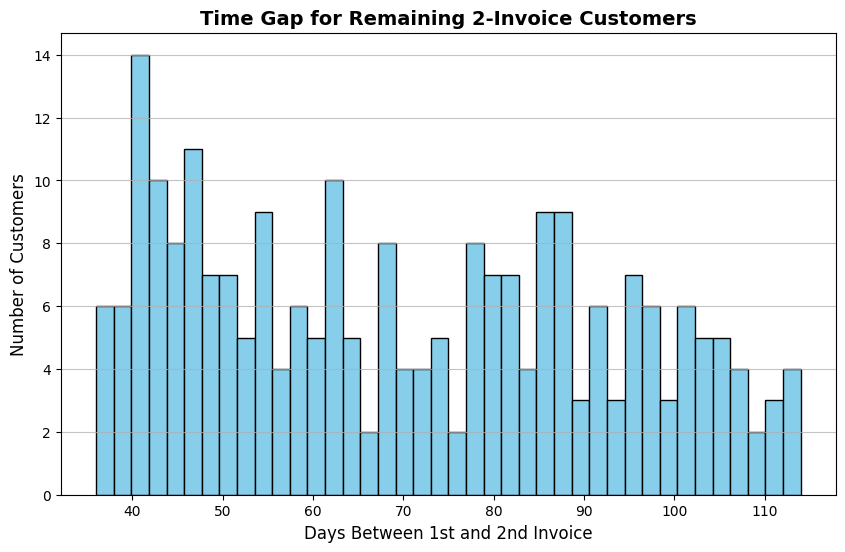

In [20]:
import matplotlib.pyplot as plt

# 1. Isolate the 2-invoice customers who are still unclassified
mask_leftover_2_invoices = (customer['total_n_invoices'] == 2) & (customer['purchase_behaviour'].isna())
leftover_ids = customer.loc[mask_leftover_2_invoices, 'CustomerHashID']

# 2. Get their 'days_between' data from the customer_dates table we made earlier
leftovers_data = customer_dates[customer_dates.index.isin(leftover_ids)]

# 3. Create the Matplotlib Histogram
plt.figure(figsize=(10, 6)) # Makes the chart a nice wide rectangle

# We use bins=40 to slice the data into small buckets (roughly 1-2 weeks each)
plt.hist(leftovers_data['days_between'], bins=40, color='skyblue', edgecolor='black')

plt.title('Time Gap for Remaining 2-Invoice Customers', fontsize=14, fontweight='bold')
plt.xlabel('Days Between 1st and 2nd Invoice', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# This adds a grid behind the bars to make it easier to read
plt.grid(axis='y', alpha=0.75) 

# Show the plot!
plt.show()

In [21]:
# ============================================================
# Setting up the 9-Quarter Matrix (For >= 2 Invoices)
# ============================================================

# 1. Filter: Unclassified AND n_invoices >= 2
mask_2_plus = (customer['purchase_behaviour'].isna()) & (customer['total_n_invoices'] >= 2)
unclassified_2_plus_ids = customer.loc[mask_2_plus, 'CustomerHashID']

# 2. Filter raw 'df' to just these remaining customers
df_seasonal = df[df['CustomerHashID'].isin(unclassified_2_plus_ids)].copy()

# 3. Create the '2009_Q4' format! 
# We combine the Year as a string, add '_Q', and then the Quarter as a string
df_seasonal['Year_Quarter'] = (
    df_seasonal['InvoiceDateMin'].dt.year.astype(str) + '_Q' + 
    df_seasonal['InvoiceDateMin'].dt.quarter.astype(str)
)

# 4. Create the Matrix using our new Year_Quarter column
q_matrix = pd.crosstab(df_seasonal['CustomerHashID'], df_seasonal['Year_Quarter'])

# 5. Convert counts to 1 (Yes) or 0 (No)
q_matrix = (q_matrix > 0).astype(int)

# 6. Force the matrix to have exactly your 9 columns in the right order. 
# (This prevents errors if nobody happened to buy in 2009_Q4)
expected_columns = [
    '2009_Q4', '2010_Q1', '2010_Q2', '2010_Q3', '2010_Q4', 
    '2011_Q1', '2011_Q2', '2011_Q3', '2011_Q4'
]
q_matrix = q_matrix.reindex(columns=expected_columns, fill_value=0)

# 7. Convert the 9 columns of 1s and 0s into a single string for each customer
q_matrix['pattern'] = q_matrix[expected_columns].astype(str).agg(''.join, axis=1)

print("B2B 9-Quarter Matrix")
print(q_matrix.head())

B2B 9-Quarter Matrix
Year_Quarter                                        2009_Q4  2010_Q1  2010_Q2  \
CustomerHashID                                                                  
00189f7baec2462e442b86d14102254df902adc5accc25e...        0        0        0   
002403301211297ae25ec229d6751c749330628e52940b7...        0        1        1   
0029315aefcd3710655f212f0d3b621343af84f1cf7aee2...        0        0        0   
0036e0e29c92201fb64bfb29e763cb17c5aa2b05f2e72b1...        0        0        0   
004881fba4811a24c786f19fb16c3cf49073ac62c60c85f...        1        1        1   

Year_Quarter                                        2010_Q3  2010_Q4  2011_Q1  \
CustomerHashID                                                                  
00189f7baec2462e442b86d14102254df902adc5accc25e...        0        0        0   
002403301211297ae25ec229d6751c749330628e52940b7...        1        1        1   
0029315aefcd3710655f212f0d3b621343af84f1cf7aee2...        0        0        1   
0036e0

In [22]:
# ============================================================
# Import the completed Excel/CSV mapping (Fixed for 2 Labels)
# ============================================================

# 1. Read the CSV you mapped in Excel
mapping_df = pd.read_csv('patterns.csv')

# 2. Ensure patterns are strings and exactly 9 characters long 
mapping_df['pattern'] = mapping_df['pattern'].astype(str).str.zfill(9)

# 3. Drop any rows that are blank in Excel
mapping_df = mapping_df.dropna(subset=['purchase_behaviour'])

# 4. Make two dictionaries
dict_behaviour = dict(zip(mapping_df['pattern'], mapping_df['purchase_behaviour']))
dict_repetition = dict(zip(mapping_df['pattern'], mapping_df['multiple_year_purchase']))

# 5. Map them to the q_matrix
q_matrix['purchase_behaviour'] = q_matrix['pattern'].map(dict_behaviour)
q_matrix['multiple_year_purchase'] = q_matrix['pattern'].map(dict_repetition)

# 6. Apply back to the main 'customer' table
# Convert matrix columns to {CustomerHashID: value} dictionaries
matched_dict_behaviour = q_matrix['purchase_behaviour'].dropna().to_dict()
matched_dict_repetition = q_matrix['multiple_year_purchase'].dropna().to_dict()

# Create mask: Only update if currently unclassified and we found a match in the dictionary
mask_truth_table = customer['purchase_behaviour'].isna() & customer['CustomerHashID'].isin(matched_dict_behaviour.keys())

# Update the main behaviour column
customer.loc[mask_truth_table, 'purchase_behaviour'] = customer.loc[mask_truth_table, 'CustomerHashID'].map(matched_dict_behaviour)

# Add/Update repetition flag column in the customer table
customer.loc[mask_truth_table, 'multiple_year_purchase'] = customer.loc[mask_truth_table, 'CustomerHashID'].map(matched_dict_repetition)

print(f"Excel Truth Table mapped {mask_truth_table.sum()} customers.")

Excel Truth Table mapped 3465 customers.


In [ ]:
summary = customer['purchase_behaviour'].value_counts(dropna=False).to_frame(name='count')

# Add the percentage column
summary['percentage'] = (summary['count'] / summary['count'].sum()) * 100

# Print (rounded to 1 decimal places)
print(summary.round(1))

                                            count  percentage
purchase_behaviour                                           
Year-round Purchase                          2237        38.4
One-Time Purchase                            1874        32.2
Yearly Adhoc One-time Repeat Purchase         387         6.6
H2 Purchase                                   337         5.8
Spring-Winter Purchase                        182         3.1
Spring-Summer Purchase                        159         2.7
Winter Season Purchase                        155         2.7
Winter-Peak Purchase                          150         2.6
H1 Purchase                                   104         1.8
Yearly Same Month One-time Repeat Purchase     92         1.6
New-Year Summer Purchase                       59         1.0
Summer-Season Purchase                         38         0.7
New-Year Purchase                              26         0.4
Spring-Season Purchase                         18         0.3
<NA>    

---
# Export data
---
---

**We push dataframe customer to folder data/processed, file B2B_customer_segmentation.parquet:**

In [25]:
# 1. Convert all text columns to 'string' dtype (safe for SQL)
text_cols = ['CustomerHashID', 'country_mode', 'region', 'sub_region', 
             'RFM_cell', 'lifecycle_segment', 'historical_value_tier', 'current_value_tier', 'historical_trajectory', 'trajectory_opportunity', 'customer_status_yoy',
             'purchase_behaviour']

for col in text_cols:
    customer[col] = customer[col].astype('string')

# 2. Fix the Boolean columns (in case they are text "TRUE"/"FALSE")
bool_cols = ['repeat_customer', 'is_left_censored', 'current_year', 'prior_year', 'multiple_year_purchase']

for col in bool_cols:
    # If they are already bools, this won't hurt them. If they are text, it fixes them.
    if customer[col].dtype == 'object' or str(customer[col].dtype) == 'string':
        customer[col] = customer[col].astype(str).str.upper().map({'TRUE': True, 'FALSE': False})
    
    customer[col] = customer[col].astype('boolean')

# 3. Round Percentage Columns
pct_cols = ['pct_business_hours', 'pct_after_hours_wkday', 'pct_weekend']

# to 3 decimal places
customer[pct_cols] = customer[pct_cols].round(3)

# 4. Make Integer
# Capital 'I' in 'Int64' for nullable integer
int_cols =['total_n_invoices', 'total_n_lines', 'total_n_skus', 'total_qty', 'max_qty_per_line' , 'n_countries', 'recency_days', 'n_active_months', 'total_active_span_days', 'ltm_n_active_months', 'R', 'F', 'M', 'RFM_score', 'ltm_recency_days', 'ltm_active_span_days', 'ltm_n_invoices', 'ltm_total_qty', 'ftm_n_active_months', 'ftm_active_span_days', 'ftm_n_invoices', 'ftm_total_qty']



customer[int_cols] = customer[int_cols].astype('Int64')

In [26]:
import os
# We use parquet format to preserve datatypes in the output file
# run pip install pyarrow in terminal if you don't have it

# Define the output path for the transformed data
output_parquet_path = '../data/processed/B2B_customer_segmentation.parquet'
output_dir = os.path.dirname(output_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(output_dir):
    print(f"❌ ERROR: The directory '{output_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(output_parquet_path):
    print(f"⏳ Exporting customer segmentation data to {output_parquet_path} ..")
    customer.to_parquet(output_parquet_path, index=False)
    print("✅ Export complete.")

# 3. If file already exists, skip the export and advise to review.
else:
    print(f"❌ File '{output_parquet_path}' already exists.")
    print("  .. Skipping export.")
    print("  Please review/delete existing file, prior to re-running this cell.")

⏳ Exporting customer segmentation data to ../data/processed/B2B_customer_segmentation.parquet ..
✅ Export complete.


---
# Table Specifications
---
---

#### **Table name:** B2B_customer_segmentation
- Fields: 45
- Rows: 5,849
- File Size: 1.1 MB
- Approximate Memory Use: 2.8 MB

| **Field** | **Description** | **Data Type** | **Example** |
| :--- | :--- | :--- | :--- |
| CustomerHashID | Pseudonymised customer number | String | 09c72970956ea... |
| n_invoices | Number of invoices | Int64 | 145 |
| n_lines | Number of line items | Int64 | 1056 |
| n_skus | Number of unique stock units | Int64 | 382 |
| total_qty | Total number of products | Int64 | 188060 |
| total_revenue | Total revenue of all purchases | Float64 | 607539.25 |
| ltm_revenue | Last 12 month revenue of purchases | Float64 | 307539.25 |
| avg_qty_per_line | Average number of products per line item | Float64 | 178.0 |
| median_qty_per_line | Median number of products per line item | Float64 | 120.0 |
| max_qty_per_line | Max number of products per line item | Int64 | 1008 |
| first_purchase | First date of purchase | Datetime64 | 2009-12-01 09:24:00 |
| last_purchase | Last date of purchase | Datetime64 | 2011-12-09 11:50:00 |
| n_countries | Number of different countries shipped to | Int64 | 1 |
| avg_basket_breadth | Average number of different products per invoice | Float64 | 7.15 |
| avg_basket_value | Average revenue per basket | Float64 | 4189.9 |
| avg_basket_qty | Average number of items per basket | Float64 | 1296.9 |
| avg_item_value | Average item price = total revenue over quantity | Float64 | 3.90 |
| active_span_days | Days between first and last purchase | Int64 | 738 |
| orders_per_month | Average number of orders per month | Float64 | 5.98 |
| recency_days | Days since last purchase | Int64 | 10 |
| repeat_customer | Flag for returning customers | Boolean | True |
| cohort_month | Month of customer's first purchase | Period(M) | 2010-09 |
| is_left_censored | Flag for customers existing prior to dataset start | Boolean | False |
| pct_case_pack_wholesale| Percentage of items bought in wholesale multiples | Float64 | 0.29 |
| pct_case_pack_metric | Percentage of items bought in metric multiples | Float64 | 0.08 |
| pct_case_pack_total | Total percentage of pack multiples | Float64 | 0.37 |
| pct_business_hours | Percentage of orders made during business hours | Float64 | 0.88 |
| pct_after_hours_wkday | Percentage of orders made during evening hours | Float64 | 0.10 |
| pct_weekend | Percentage of orders made on the weekend | Float64 | 0.02 |
| country_mode | Most frequent country of purchase | String | IRELAND |
| rev_slope | Linear trend of revenue over active months | Float64 | -270.76 |
| rev_slope_pct | Percentage trend of revenue over active months | Float64 | -0.01 |
| n_active_months | Number of distinct months with a purchase | Int64 | 13 |
| region | Broad geographic region | String | APAC |
| sub_region | Specific geographic sub-region | String | OCEANIA |
| R | Recency score (1-5) | Int64 | 5 |
| F | Frequency score (1-5) | Int64 | 4 |
| M | Monetary score (1-5) | Int64 | 5 |
| RFM_score | Combined R + F + M score (Sum) | Int64 | 14 |
| RFM_cell | Combined R + F + M cell (Concatenation) | String | 545 |
| lifecycle_segment | Behavioral customer segmentation | String | Champions |
| hist_cum_rev_pct | Cumulative total revenue percentile | Float64 | 0.37 |
| historical_value_tier | Full Value tier based on 80/20 Pareto rule | String | Key Account |
| curr_cum_rev_pct | Cumulative 12 month revenue percentile | Float64 | 0.83 |
| current_value_tier | Current Value tier based on 80/20 Pareto rule | String | Core Account |
| trajectory | Customer spend momentum (Growing/Stable/Declining) | String | Growing |
| purchase_behaviour | Customer seasonality profile | String | Year-round |
| multiple_year_purchase | Made purchases in more than one calendar year | Boolean | True |

In [27]:
# Check column names, data types, and non-null counts
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 5821 entries, 0 to 5820
Data columns (total 76 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   CustomerHashID               5821 non-null   string        
 1   total_n_invoices             5821 non-null   Int64         
 2   total_n_lines                5821 non-null   Int64         
 3   total_n_skus                 5821 non-null   Int64         
 4   total_qty                    5821 non-null   Int64         
 5   total_revenue                5821 non-null   float64       
 6   avg_qty_per_line             5821 non-null   float64       
 7   median_qty_per_line          5821 non-null   float64       
 8   max_qty_per_line             5821 non-null   Int64         
 9   first_purchase               5821 non-null   datetime64[us]
 10  last_purchase                5821 non-null   datetime64[us]
 11  n_countries                  5821 non-null   Int64    

In [3]:
import os
# We use parquet format to preserve datatypes in the output file
# run pip install pyarrow in terminal if you don't have it

# Define the output path for the transformed data
output_parquet_path = '../data/processed/B2B_customer_orders.parquet'
output_dir = os.path.dirname(output_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(output_dir):
    print(f"❌ ERROR: The directory '{output_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(output_parquet_path):
    print(f"⏳ Exporting customer orders data to {output_parquet_path} ..")
    df.to_parquet(output_parquet_path, index=False)
    print("✅ Export complete.")

# 3. If file already exists, skip the export and advise to review.
else:
    print(f"❌ File '{output_parquet_path}' already exists.")
    print("  .. Skipping export.")
    print("  Please review/delete existing file, prior to re-running this cell.")

⏳ Exporting customer orders data to ../data/processed/B2B_customer_orders.parquet ..
✅ Export complete.


---
---
---
# Testing

In [3]:
# Rules for clean data filter to then get representative B2B and B2C customer profiles:
#  StockCodeType	= PRODUCT
#  DescriptionType  = PRODUCT
#  CancellationType = NaN
#  OrderCheckout    = CUSTOMER ACCOUNT
#  Gives 801,095 out of 1,067,371 -> 75% base for customer profile

# ========================================
# first we collapse data to customer level
# ========================================

import pandas as pd
import numpy as np

# Apply customer base filter rules
mask = (
    (df_cleansed_online_retail_orders['StockCodeType']    == 'PRODUCT') &
    (df_cleansed_online_retail_orders['DescriptionType']  == 'PRODUCT') &
    (df_cleansed_online_retail_orders['CancellationType'].isna()) &
    (df_cleansed_online_retail_orders['OrderCheckout']    == 'CUSTOMER ACCOUNT')
)
df_old = df_cleansed_online_retail_orders.loc[mask].dropna(subset=['CustomerHashID']).copy()


# Define anchor dates
max_dataset_date = df_old['InvoiceDateMin'].max() # Ends Nov 30, 2011


# Per-invoice breadth (distinct SKUs in a basket)
inv_breadth = (df_old.groupby(['CustomerHashID','Invoice'])['StockCode']
                 .nunique().reset_index(name='breadth'))
inv_value   = (df_old.groupby(['CustomerHashID','Invoice'])['TotalPrice']
                 .sum().reset_index(name='basket_value'))
inv_qty     = (df_old.groupby(['CustomerHashID','Invoice'])['Quantity']
                 .sum().reset_index(name='basket_qty'))

# =================================================
# 1 Customer-level aggregations full trading window
# =================================================

customer_old = df_old.groupby('CustomerHashID').agg(
    total_n_invoices    = ('Invoice',         'nunique'),
    total_n_lines       = ('Invoice',         'size'),
    total_n_skus        = ('StockCode',       'nunique'),
    total_qty           = ('Quantity',        'sum'),
    total_revenue       = ('TotalPrice',      'sum'),
    avg_qty_per_line    = ('Quantity',        'mean'),
    median_qty_per_line = ('Quantity',        'median'),
    max_qty_per_line    = ('Quantity',        'max'),
    first_purchase      = ('InvoiceDateMin',  'min'),
    last_purchase       = ('InvoiceDateMin',  'max'),
    n_countries         = ('Country',         'nunique'),
).reset_index()

# Recency of full data set
customer_old['recency_days'] = (max_dataset_date - customer_old['last_purchase']).dt.days

# Number of active months for full data set
n_active_months = (df_old.assign(month=df_old['InvoiceDateMin'].dt.to_period('M'))
                     .groupby('CustomerHashID')['month']
                     .nunique()
                     .rename('n_active_months'))

# customer = customer.drop(columns=['n_active_months'], errors='ignore')
customer_old = customer_old.merge(n_active_months, on='CustomerHashID', how='left')

customer_old = (customer_old
    .merge(inv_breadth.groupby('CustomerHashID')['breadth'].mean()
                       .rename('avg_basket_breadth'), on='CustomerHashID')
    .merge(inv_value.groupby('CustomerHashID')['basket_value'].mean()
                     .rename('avg_basket_value'), on='CustomerHashID')
    .merge(inv_qty.groupby('CustomerHashID')['basket_qty'].mean()
                   .rename('avg_basket_qty'), on='CustomerHashID')
)

# Calculate average item value
customer_old['avg_item_value'] = customer_old['total_revenue'] / customer_old['total_qty']

# we don't know tenure so we use active span for the trading window, between first and last purchase (min 1 day)
customer_old['total_active_span_days'] = (customer_old['last_purchase'] - customer_old['first_purchase']).dt.days.clip(lower=1)

# To handle first day orders defaulting to 30.44 orders force the minimum window to be 1 month (30.44 days)
math_span_days = (customer_old['last_purchase'] - customer_old['first_purchase']).dt.days.clip(lower=30.44)
customer_old['orders_per_month'] = customer_old['total_n_invoices'] / (math_span_days / 30.44)

customer_old['repeat_customer']  = customer_old['total_n_invoices'] > 1

# we add a cohort month for analysis that requires customer age
customer_old['cohort_month'] = customer_old['first_purchase'].dt.to_period('M')


# Clean up formatting
customer_old['total_revenue'] = customer_old['total_revenue'].round(2)
customer_old['avg_qty_per_line'] = customer_old['avg_qty_per_line'].round(1)
customer_old['avg_basket_breadth'] = customer_old['avg_basket_breadth'].round(1)
customer_old['avg_basket_value'] = customer_old['avg_basket_value'].round(2)
customer_old['avg_basket_qty'] = customer_old['avg_basket_qty'].round(1)
customer_old['avg_item_value'] = customer_old['avg_item_value'].round(2)
customer_old['orders_per_month'] = customer_old['orders_per_month'].round(1)

print(customer_old.shape)
customer_old.head()

(5849, 22)


,CustomerHashID,total_n_invoices,total_n_lines,total_n_skus,total_qty,total_revenue,avg_qty_per_line,median_qty_per_line,max_qty_per_line,first_purchase,...,recency_days,n_active_months,avg_basket_breadth,avg_basket_value,avg_basket_qty,avg_item_value,total_active_span_days,orders_per_month,repeat_customer,cohort_month
0,00189f7baec2462e442b86d14102254df902adc5accc25...,11,189,172,2165,3349.57,11.5,12.0,48,2011-05-18 11:42:00,...,10,6,17.2,304.51,196.8,1.55,194,1.7,True,2011-05
1,002403301211297ae25ec229d6751c749330628e52940b...,9,115,30,1955,4049.79,17.0,16.0,40,2010-02-09 11:46:00,...,108,8,12.8,449.98,217.2,2.07,559,0.5,True,2010-02
2,0029315aefcd3710655f212f0d3b621343af84f1cf7aee...,4,9,3,162,420.30,18.0,24.0,24,2011-03-09 08:59:00,...,9,4,2.2,105.08,40.5,2.59,265,0.5,True,2011-03
3,0036e0e29c92201fb64bfb29e763cb17c5aa2b05f2e72b...,6,12,7,1233,1133.25,102.8,50.0,200,2011-07-12 09:11:00,...,6,5,2.0,188.88,205.5,0.92,143,1.3,True,2011-07
4,00386273912716004a52cf88eca0d3db7fb54734d0601f...,1,45,45,386,1693.88,8.6,8.0,24,2011-01-27 10:19:00,...,316,1,45.0,1693.88,386.0,4.39,1,1.0,False,2011-01


#### This is to test the orders we chopped off are indeed Dec 2011

In [5]:
import pandas as pd

# 1. Perform a left join with indicator=True
# This adds a column called '_merge' that tells us if the ID was in 'both', 'left_only', or 'right_only'
check_df = customer_old.merge(
    customer[['CustomerHashID']], # We only need the ID column from the customer table
    on='CustomerHashID', 
    how='left', 
    indicator=True
)

# 2. Filter for customers who are ONLY in the raw orders table (meaning they got dropped)
missing_orders = check_df[check_df['_merge'] == 'left_only']

# 3. Group by these missing customers to see exactly WHEN they were shopping
missing_customers_summary = missing_orders.groupby('CustomerHashID').agg(
    first_order_date=('first_purchase', 'min'),
    last_order_date=('last_purchase', 'max'),
    total_invoices=('CustomerHashID', 'nunique')
).reset_index()

# 4. Display 25 random examples for you to check
print(f"Total dropped customers found: {missing_customers_summary.shape[0]}")
display(missing_customers_summary.head(29))

Total dropped customers found: 28


,CustomerHashID,first_order_date,last_order_date,total_invoices
0,0c816f296a880f78b9297f1f9d6a48078cd02ee154c430...,2011-12-05 14:49:00,2011-12-05 14:49:00,1
1,216a6229deeb40b1dcc3c6f1d8e67b7bc7f0ff59701e37...,2011-12-04 12:14:00,2011-12-04 12:14:00,1
2,3524deb60898f95efbc4742942efd720ea5ae60aa1fa7e...,2011-12-06 16:34:00,2011-12-06 16:34:00,1
3,37f2c4dd3539e9a82532f5ef33f6d8c846893f8033b06f...,2011-12-01 14:50:00,2011-12-01 14:50:00,1
4,3b61411cb9379170cba2949f2132db99e6bed02df22840...,2011-12-08 10:58:00,2011-12-08 10:58:00,1
5,4047a9c526ebeb053316e3966ba10fa7728c7187bda64c...,2011-12-06 12:45:00,2011-12-06 12:45:00,1
6,47f1aaed8ec856192eb8f5ad1ba531a098166cb01f7af6...,2011-12-06 14:22:00,2011-12-06 14:22:00,1
7,51513c9213d2678c4d35083fd0bcf352d632e969d7585e...,2011-12-05 16:48:00,2011-12-05 16:48:00,1
8,65f126c748ba018c3da449d927d95ad697c604c26e67e9...,2011-12-09 12:16:00,2011-12-09 12:16:00,1
9,707d53e41cf81b4db2e48719793224fc2413b3315da56f...,2011-12-05 15:44:00,2011-12-05 15:44:00,1


---
---
### Check Revenue - Testing

In [3]:
import pandas as pd


df = df_cleansed_online_retail_orders.copy()


# 1. Ensure InvoiceDateMin is in datetime format (if it isn't already)
df['InvoiceDateMin'] = pd.to_datetime(df['InvoiceDateMin'])

# 2. Create a temporary Year-Month column 
# (You can do this inside the groupby or as a new column)
df['YearMonth'] = df['InvoiceDateMin'].dt.to_period('M')

# 3. Group by YearMonth and OrderCheckout
# Aggregate CustomerHashID using 'nunique' and TotalPrice using 'sum'
summary_df = df.groupby(['YearMonth', 'OrderCheckout']).agg({
    'CustomerHashID': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

# 4. Rename the columns for better clarity
summary_df.columns = ['YearMonth', 'OrderCheckout', 'Distinct_Customers', 'Sum_TotalPrice']

# Optional: Convert YearMonth back to string if you need to export to CSV/Excel
# summary_df['YearMonth'] = summary_df['YearMonth'].astype(str)

print(summary_df.head())

  YearMonth         OrderCheckout  Distinct_Customers  Sum_TotalPrice
0   2009-12      CUSTOMER ACCOUNT                1044       663158.55
1   2009-12        GUEST CHECKOUT                   0       136575.06
2   2009-12          TEST ACCOUNT                   0          113.50
3   2009-12  WAREHOUSE ADJUSTMENT                   0            0.00
4   2010-01      CUSTOMER ACCOUNT                 786       531862.90


In [ ]:
mask = (
    (df_cleansed_online_retail_orders['StockCodeType']    == 'PRODUCT') &
    (df_cleansed_online_retail_orders['DescriptionType']  == 'PRODUCT') &
    (df_cleansed_online_retail_orders['CancellationType'].isna()) &
    (df_cleansed_online_retail_orders['OrderCheckout']    == 'CUSTOMER ACCOUNT')
)
df = df_cleansed_online_retail_orders.loc[mask].dropna(subset=['CustomerHashID']).copy()

In [6]:
df_mask = ((df_cleansed_online_retail_orders['OrderCheckout']    == 'CUSTOMER ACCOUNT'))
df_orders = df_cleansed_online_retail_orders.loc[df_mask].dropna(subset=['CustomerHashID']).copy()

In [7]:
import pandas as pd

# 1. Ensure InvoiceDateMin is in datetime format
df_orders['InvoiceDateMin'] = pd.to_datetime(df_orders['InvoiceDateMin'])

# 2. Create the Year-Month period column
df_orders['YearMonth'] = df_orders['InvoiceDateMin'].dt.to_period('M')

# 3. Group by YearMonth and the three specified categorical columns
# Note: dropna=False is included so that orders with 'None' or empty values 
# in these categories are still included in your sums.
summary2_df = df_orders.groupby(
    ['YearMonth', 'StockCodeType', 'DescriptionType', 'CancellationType'], 
    dropna=False
).agg({
    'CustomerHashID': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

# 4. Rename the result columns for clarity
summary2_df.columns = [
    'YearMonth', 
    'StockCodeType', 
    'DescriptionType', 
    'CancellationType', 
    'Distinct_Customers', 
    'Sum_TotalPrice'
]

# Display the first few rows
print(summary2_df.head())

  YearMonth StockCodeType DescriptionType CancellationType  \
0   2009-12  BANK CHARGES    BANK CHARGES     CANCELLATION   
1   2009-12  BANK CHARGES    BANK CHARGES              NaN   
2   2009-12      CARRIAGE        CARRIAGE              NaN   
3   2009-12      DISCOUNT        DISCOUNT     CANCELLATION   
4   2009-12        MANUAL          MANUAL     CANCELLATION   

   Distinct_Customers  Sum_TotalPrice  
0                   1          -15.00  
1                   1           15.00  
2                   5          350.00  
3                   5         -108.91  
4                   6        -2908.77  


In [8]:
mask_1_cleanse = (
    (df_cleansed_online_retail_orders['StockCodeType']    == 'PRODUCT') &
    (df_cleansed_online_retail_orders['DescriptionType']  == 'PRODUCT') &
    (df_cleansed_online_retail_orders['CancellationType'].isna()) &
    (df_cleansed_online_retail_orders['OrderCheckout']    == 'CUSTOMER ACCOUNT')
)
df_cleanse1 = df_cleansed_online_retail_orders.loc[mask_1_cleanse].dropna(subset=['CustomerHashID']).copy()


import pandas as pd

# 1. Ensure InvoiceDateMin is in datetime format
df_cleanse1['InvoiceDateMin'] = pd.to_datetime(df_cleanse1['InvoiceDateMin'])

# 2. Create the Year-Month period column
df_cleanse1['YearMonth'] = df_cleanse1['InvoiceDateMin'].dt.to_period('M')

# 3. Group by YearMonth and the three specified categorical columns
# Note: dropna=False is included so that orders with 'None' or empty values 
# in these categories are still included in your sums.
summary_df_rule1 = df_cleanse1.groupby(
    ['YearMonth', 'StockCodeType', 'DescriptionType', 'CancellationType'], 
    dropna=False
).agg({
    'CustomerHashID': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

# 4. Rename the result columns for clarity
summary_df_rule1.columns = [
    'YearMonth', 
    'StockCodeType', 
    'DescriptionType', 
    'CancellationType', 
    'Distinct_Customers', 
    'Sum_TotalPrice'
]

# Display the first few rows
print(summary_df_rule1.head())

  YearMonth StockCodeType DescriptionType CancellationType  \
0   2009-12       PRODUCT         PRODUCT              NaN   
1   2010-01       PRODUCT         PRODUCT              NaN   
2   2010-02       PRODUCT         PRODUCT              NaN   
3   2010-03       PRODUCT         PRODUCT              NaN   
4   2010-04       PRODUCT         PRODUCT              NaN   

   Distinct_Customers  Sum_TotalPrice  
0                 949       679378.72  
1                 700       534844.24  
2                 769       499072.35  
3                1050       667234.00  
4                 939       585734.74  


In [10]:
import pandas as pd

# 3. Group by BOTH columns inside ONE list
summary_df_rule2 = customer.groupby(
    ['CustomerHashID', 'cohort_month'], # <--- Fixed: both inside one set of brackets
    dropna=False
).agg({
    'total_revenue': 'sum'
}).reset_index()

# 4. Rename the result columns 
# (You have 3 columns now: the two you grouped by + the sum result)
summary_df_rule2.columns = [
    'CustomerHashID', 
    'cohort_month', 
    'Sum_TotalRevenue'
]

# Display the first few rows
print(summary_df_rule2.head())

                                      CustomerHashID cohort_month  \
0  00189f7baec2462e442b86d14102254df902adc5accc25...      2011-05   
1  002403301211297ae25ec229d6751c749330628e52940b...      2010-02   
2  0029315aefcd3710655f212f0d3b621343af84f1cf7aee...      2011-03   
3  0036e0e29c92201fb64bfb29e763cb17c5aa2b05f2e72b...      2011-07   
4  00386273912716004a52cf88eca0d3db7fb54734d0601f...      2011-01   

   Sum_TotalRevenue  
0           3349.57  
1           4049.79  
2            420.30  
3           1093.65  
4           1693.88  


In [ ]:
# Rules for clean data filter to then get representative B2B and B2C customer profiles:
#  StockCodeType	= PRODUCT
#  DescriptionType  = PRODUCT
#  CancellationType = NaN
#  OrderCheckout    = CUSTOMER ACCOUNT
#  Gives 801,095 out of 1,067,371 -> 75% base for customer profile

# ========================================
# first we collapse data to customer level
# ========================================

import pandas as pd
import numpy as np

# Apply customer base filter rules
mask = (
    (df_cleansed_online_retail_orders['StockCodeType']    == 'PRODUCT') &
    (df_cleansed_online_retail_orders['DescriptionType']  == 'PRODUCT') &
    (df_cleansed_online_retail_orders['CancellationType'].isna()) &
    (df_cleansed_online_retail_orders['OrderCheckout']    == 'CUSTOMER ACCOUNT')
)
df = df_cleansed_online_retail_orders.loc[mask].dropna(subset=['CustomerHashID']).copy()

# ============================================================
# Sanity Check: TotalPrice <= 0 
# ============================================================

# 1. Count how many rows have a TotalPrice of 0 or less
mask_invalid_price = df['TotalPrice'] == 0
invalid_count = mask_invalid_price.sum()

print(f"Found {invalid_count} rows with TotalPrice == 0")

# 2. (Optional) View a sample of them to see what's going on (e.g., biscuit tins!)
if invalid_count > 0:
    print(df[mask_invalid_price][['CustomerHashID', 'InvoiceDateMin', 'TotalPrice']].head())

# 3. Cleanse the dataframe by keeping ONLY rows where TotalPrice > 0
# (Run this early in your script before generating customer['n_invoices'])
df = df[df['TotalPrice'] > 0].copy()

# ============================================================
# Cut off exactly at midnight before Dec 1, 2011
# ============================================================
df = df[df['InvoiceDateMin'] < '2011-12-01'].copy()

# Define anchor dates
max_dataset_date = df['InvoiceDateMin'].max() # Ends Nov 30, 2011
ltm_start = pd.to_datetime('2010-12-01') # last twelve month start
ltm_end = pd.to_datetime('2011-11-30')
ftm_start = pd.to_datetime('2009-12-01') # first twelve month start for YoY comparisons
ftm_end = pd.to_datetime('2010-11-30')

# Per-invoice breadth (distinct SKUs in a basket)
inv_breadth = (df.groupby(['CustomerHashID','Invoice'])['StockCode']
                 .nunique().reset_index(name='breadth'))
inv_value   = (df.groupby(['CustomerHashID','Invoice'])['TotalPrice']
                 .sum().reset_index(name='basket_value'))
inv_qty     = (df.groupby(['CustomerHashID','Invoice'])['Quantity']
                 .sum().reset_index(name='basket_qty'))

# =================================================
# 1 Customer-level aggregations full trading window
# =================================================

customer = df.groupby('CustomerHashID').agg(
    total_n_invoices    = ('Invoice',         'nunique'),
    total_n_lines       = ('Invoice',         'size'),
    total_n_skus        = ('StockCode',       'nunique'),
    total_qty           = ('Quantity',        'sum'),
    total_revenue       = ('TotalPrice',      'sum'),
    avg_qty_per_line    = ('Quantity',        'mean'),
    median_qty_per_line = ('Quantity',        'median'),
    max_qty_per_line    = ('Quantity',        'max'),
    first_purchase      = ('InvoiceDateMin',  'min'),
    last_purchase       = ('InvoiceDateMin',  'max'),
    n_countries         = ('Country',         'nunique'),
).reset_index()

# Recency of full data set
customer['recency_days'] = (max_dataset_date - customer['last_purchase']).dt.days

# Number of active months for full data set
n_active_months = (df.assign(month=df['InvoiceDateMin'].dt.to_period('M'))
                     .groupby('CustomerHashID')['month']
                     .nunique()
                     .rename('n_active_months'))

# customer = customer.drop(columns=['n_active_months'], errors='ignore')
customer = customer.merge(n_active_months, on='CustomerHashID', how='left')

customer = (customer
    .merge(inv_breadth.groupby('CustomerHashID')['breadth'].mean()
                       .rename('avg_basket_breadth'), on='CustomerHashID', how='left')
    .merge(inv_value.groupby('CustomerHashID')['basket_value'].mean()
                     .rename('avg_basket_value'), on='CustomerHashID', how='left')
    .merge(inv_qty.groupby('CustomerHashID')['basket_qty'].mean()
                   .rename('avg_basket_qty'), on='CustomerHashID', how='left')
)

# Calculate average item value
customer['avg_item_value'] = customer['total_revenue'] / customer['total_qty']

# we don't know tenure so we use active span for the trading window, between first and last purchase (min 1 day)
customer['total_active_span_days'] = (customer['last_purchase'] - customer['first_purchase']).dt.days.clip(lower=1)

# To handle first day orders defaulting to 30.44 orders force the minimum window to be 1 month (30.44 days)
math_span_days = (customer['last_purchase'] - customer['first_purchase']).dt.days.clip(lower=30.44)
customer['orders_per_month'] = customer['total_n_invoices'] / (math_span_days / 30.44)

customer['repeat_customer']  = customer['total_n_invoices'] > 1

# we add a cohort month for analysis that requires customer age
customer['cohort_month'] = customer['first_purchase'].dt.to_period('M')

# we flag customers first purchase within 30 days of window as left-censored since we don't know when they actually started
data_start = df['InvoiceDateMin'].min()
buffer = pd.Timedelta(days=30)
customer['is_left_censored'] = customer['first_purchase'] <= (data_start + buffer)

# Clean up formatting
customer['total_revenue'] = customer['total_revenue'].round(2)
customer['avg_qty_per_line'] = customer['avg_qty_per_line'].round(1)
customer['avg_basket_breadth'] = customer['avg_basket_breadth'].round(1)
customer['avg_basket_value'] = customer['avg_basket_value'].round(2)
customer['avg_basket_qty'] = customer['avg_basket_qty'].round(1)
customer['avg_item_value'] = customer['avg_item_value'].round(2)
customer['orders_per_month'] = customer['orders_per_month'].round(1)

print(customer.shape)
customer.head()

In [ ]:
# Rules for clean data filter to then get representative B2B and B2C customer profiles:
#  StockCodeType	= PRODUCT
#  DescriptionType  = PRODUCT
#  CancellationType = NaN
#  OrderCheckout    = CUSTOMER ACCOUNT
#  Gives 801,095 out of 1,067,371 -> 75% base for customer profile

# ========================================
# first we collapse data to customer level
# ========================================

import pandas as pd
import numpy as np

# Apply customer base filter rules
mask = (
    (df_cleansed_online_retail_orders['StockCodeType']    == 'PRODUCT') &
    (df_cleansed_online_retail_orders['DescriptionType']  == 'PRODUCT') &
    (df_cleansed_online_retail_orders['CancellationType'].isna()) &
    (df_cleansed_online_retail_orders['OrderCheckout']    == 'CUSTOMER ACCOUNT')
)
df = df_cleansed_online_retail_orders.loc[mask].dropna(subset=['CustomerHashID']).copy()

# ============================================================
# Sanity Check: TotalPrice <= 0 
# ============================================================

# 1. Count how many rows have a TotalPrice of 0 or less
mask_invalid_price = df['TotalPrice'] == 0
invalid_count = mask_invalid_price.sum()

print(f"Found {invalid_count} rows with TotalPrice == 0")

# 2. (Optional) View a sample of them to see what's going on (e.g., biscuit tins!)
if invalid_count > 0:
    print(df[mask_invalid_price][['CustomerHashID', 'InvoiceDateMin', 'TotalPrice']].head())

# 3. Cleanse the dataframe by keeping ONLY rows where TotalPrice > 0
# (Run this early in your script before generating customer['n_invoices'])
df = df[df['TotalPrice'] > 0].copy()

# ============================================================
# Cut off exactly at midnight before Dec 1, 2011
# ============================================================
df = df[df['InvoiceDateMin'] < '2011-12-01'].copy()

# Define anchor dates
max_dataset_date = df['InvoiceDateMin'].max() # Ends Nov 30, 2011
ltm_start = pd.to_datetime('2010-12-01') # last twelve month start
ltm_end = pd.to_datetime('2011-11-30')
ftm_start = pd.to_datetime('2009-12-01') # first twelve month start for YoY comparisons
ftm_end = pd.to_datetime('2010-11-30')

# Per-invoice breadth (distinct SKUs in a basket)
inv_breadth = (df.groupby(['CustomerHashID','Invoice'])['StockCode']
                 .nunique().reset_index(name='breadth'))
inv_value   = (df.groupby(['CustomerHashID','Invoice'])['TotalPrice']
                 .sum().reset_index(name='basket_value'))
inv_qty     = (df.groupby(['CustomerHashID','Invoice'])['Quantity']
                 .sum().reset_index(name='basket_qty'))

# =================================================
# 1 Customer-level aggregations full trading window
# =================================================

customer = df.groupby('CustomerHashID').agg(
    total_n_invoices    = ('Invoice',         'nunique'),
    total_n_lines       = ('Invoice',         'size'),
    total_n_skus        = ('StockCode',       'nunique'),
    total_qty           = ('Quantity',        'sum'),
    total_revenue       = ('TotalPrice',      'sum'),
    avg_qty_per_line    = ('Quantity',        'mean'),
    median_qty_per_line = ('Quantity',        'median'),
    max_qty_per_line    = ('Quantity',        'max'),
    first_purchase      = ('InvoiceDateMin',  'min'),
    last_purchase       = ('InvoiceDateMin',  'max'),
    n_countries         = ('Country',         'nunique'),
).reset_index()

# Recency of full data set
customer['recency_days'] = (max_dataset_date - customer['last_purchase']).dt.days

# Number of active months for full data set
n_active_months = (df.assign(month=df['InvoiceDateMin'].dt.to_period('M'))
                     .groupby('CustomerHashID')['month']
                     .nunique()
                     .rename('n_active_months'))

# customer = customer.drop(columns=['n_active_months'], errors='ignore')
customer = customer.merge(n_active_months, on='CustomerHashID', how='left')

customer = (customer
    .merge(inv_breadth.groupby('CustomerHashID')['breadth'].mean()
                       .rename('avg_basket_breadth'), on='CustomerHashID', how='left')
    .merge(inv_value.groupby('CustomerHashID')['basket_value'].mean()
                     .rename('avg_basket_value'), on='CustomerHashID', how='left')
    .merge(inv_qty.groupby('CustomerHashID')['basket_qty'].mean()
                   .rename('avg_basket_qty'), on='CustomerHashID', how='left')
)

# Calculate average item value
customer['avg_item_value'] = customer['total_revenue'] / customer['total_qty']

# we don't know tenure so we use active span for the trading window, between first and last purchase (min 1 day)
customer['total_active_span_days'] = (customer['last_purchase'] - customer['first_purchase']).dt.days.clip(lower=1)

# To handle first day orders defaulting to 30.44 orders force the minimum window to be 1 month (30.44 days)
math_span_days = (customer['last_purchase'] - customer['first_purchase']).dt.days.clip(lower=30.44)
customer['orders_per_month'] = customer['total_n_invoices'] / (math_span_days / 30.44)

customer['repeat_customer']  = customer['total_n_invoices'] > 1

# we add a cohort month for analysis that requires customer age
customer['cohort_month'] = customer['first_purchase'].dt.to_period('M')

# we flag customers first purchase within 30 days of window as left-censored since we don't know when they actually started
data_start = df['InvoiceDateMin'].min()
buffer = pd.Timedelta(days=30)
customer['is_left_censored'] = customer['first_purchase'] <= (data_start + buffer)

# Clean up formatting
customer['total_revenue'] = customer['total_revenue'].round(2)
customer['avg_qty_per_line'] = customer['avg_qty_per_line'].round(1)
customer['avg_basket_breadth'] = customer['avg_basket_breadth'].round(1)
customer['avg_basket_value'] = customer['avg_basket_value'].round(2)
customer['avg_basket_qty'] = customer['avg_basket_qty'].round(1)
customer['avg_item_value'] = customer['avg_item_value'].round(2)
customer['orders_per_month'] = customer['orders_per_month'].round(1)

print(customer.shape)
customer.head()